In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import seaborn as sns
from matplotlib import pyplot as plt
from src.data_format import format_output
from src.data import DATA_OUT_PROC, DATA_FIGURE, DATA_IN_JSONS, DATA_LABELLED
from src.accuracy import *
from src.utils import *
from src.impact_def import IMPACT_SUBTYPES_MERGED
from src.utils import MODEL_NAMES_MAP


[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/lseverino/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to /Users/lseverino/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/lseverino/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## Coverage with accuracy

In [2]:
# load data extracted for a specific model


keys = ["meta-llama_llama-4-scout-17b-16e-instruct", "llama-3.1-8b-instant", "llama-3.3-70b-versatile"]
key = keys[0]
res_savename_ext = "post_processed_labelled_reports_1quali_chunksize1000_Noneit_meta-llama_llama-4-scout-17b-16e-instruct_v180426_v180426_geo"
# "post_processed_test_reports_gaps_chunksize1000_llama-3.3-70b-versatile_v060426_v060426_geo"
# "post_processed_labelled_reports_gaps_llama-3.3-70b-versatile_v270326_v270326_geo"  # merged_subtypes_

# load data (labelled)
res_savename_lab = "post_processed_labelled_reports_impacts_gaps_v050426_v070426_geo"

split_lowest = False
suffix = "_geo_split_lowest" if split_lowest else "_geo"
suffix2 = suffix + "_v271025"
suffix3 = suffix + "_v171025"
# load geocoded data
extracted_df = gpd.read_file(DATA_OUT_PROC / (res_savename_ext+".gpkg"))
labelled_df = gpd.read_file(DATA_OUT_PROC / (res_savename_lab+".gpkg"))
# load corresponding matched data
ws_key_qt = "ws_quanti_opt"
ws_key_ql = "ws_quali_opt"
filename_match = f"matched_data_by_labelled_{ws_key_qt}qt-{ws_key_ql}ql-geo-valuepre-loose-nans_{res_savename_ext}"
# f"matched_data_ws2-geo-valuepre-strict-nans_{res_savename_ext}"
matched_df = gpd.read_feather(DATA_OUT_PROC / (filename_match + ".feather"))

DEF_CRS_EPSG = "EPSG:4326"
drop_appeals = [
    "MDRCO023",
    "MDRGW003",
    "MDRHU005",
    "MDRPH021",
    "MDRRS015",
    "MDRMN017",
    "MDRGT009",
    "MDRPG008",
    "MDREC019",
    "MDRTN010",
    "MDRCR012",
    "MDRGE019",]
keep_appeals = [appeal for appeal in extracted_df["appealCode"].unique() if appeal not in drop_appeals]
for name in ["matched_df", "extracted_df", "labelled_df"]:
    df = locals()[name]
    if "quanti" not in df.columns:
        df["quanti"] = df["impactValue"].notnull()
        df.loc[df["quanti"],"quanti"] = "quanti"
        df.loc[df["quanti"]==False,"quanti"] = "quali"
    df = df.set_crs(DEF_CRS_EPSG, allow_override=True)
    df = df[df["appealCode"].isin(keep_appeals)]
    locals()[name] = df  # assign back

# compute metrics
matched_df["impactValue_error"] = matched_df["impactValue_error"].replace([np.inf], np.nan)
matched_df["impactValue_sim"] = matched_df.apply(lambda x: 1-max_value_diff(x["impactValue"], x["impactValue_matched"]).clip(0,1), axis=1)

In [3]:
labelled_df.impactSubtype.value_counts()

impactSubtype
Affected People                                100
Residential Buildings                           88
Agriculture and Access to Food                  42
Displaced People                                32
Water, Sanitation, and Hygiene                  31
Transportation                                  25
Infected and Ill People                         24
Economy and Livelihood                          23
Human Deaths                                    23
Undefined Infrastructure and Service Access     21
Healthcare                                      14
Injured People                                  13
Human Health and Wellbeing                      10
Informal Settlements                             9
Education                                        9
Homeless People                                  9
Missing People                                   5
Power and Energy Production                      3
Recreation, Tourism, and Culture                 1
IT and Communicat

In [4]:
extracted_df.impactSubtype.value_counts()

impactSubtype
Affected People                                110
Residential Buildings                           79
Agriculture and Access to Food                  55
Water, Sanitation, and Hygiene                  48
Displaced People                                48
Infected and Ill People                         32
Homeless People                                 28
DREF Allocation & Funding requirements          28
Human Deaths                                    24
Transportation                                  24
Human Health and Wellbeing                      23
Economy and Livelihood                          22
Assisted People                                 22
Healthcare                                      20
Targeted People                                 20
Injured People                                  15
Education                                       12
Missing People                                   5
Undefined Infrastructure and Service Access      4
Power and Energy 

In [5]:
## add other variables useful for analysis
# report length
extracted_df["reportSize"] = extracted_df["nathaz_text"].apply(len)

# report type
file_path = (
    DATA_IN_JSONS
    / "preproc_text_sel_gaps_all_ifrc_reports_info_unnested_with_text_v181125_v050326.csv"
)  #'all_ifrc_reports_info_processed_extended_format_nb_std_units.json' "nathaz_ifrc_reports_info_processed.json"
ifrc_reports_df = pd.read_csv(file_path)

keys = labelled_df[['appealCode', 'reportDate']].drop_duplicates()
labelled_reports_raw = ifrc_reports_df.merge(keys, on=['appealCode', 'reportDate'], how='inner')


# add vars to dfs
#extracted_df = extracted_df.merge(labelled_reports_raw[["appealCode", "reportDate", "appealType"]], how="left", on=["appealCode", "reportDate"])
#labelled_df = labelled_df.merge(labelled_reports_raw[["appealCode", "reportDate", "appealType"]], how="left", on=["appealCode", "reportDate"])
#matched_df = matched_df.merge(labelled_reports_raw[["appealCode", "reportDate", "appealType"]], how="left", on=["appealCode", "reportDate"])

In [6]:
from src.labelling_helpers import filter_reports
ifrc_reports_df_filtered = filter_reports(ifrc_reports_df, take_latest=True)


/Users/lseverino/Documents/PhD/Projects/Como/como_project4/src/labelling_helpers.py:76: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: sort_appeal_type(x))
/Users/lseverino/Documents/PhD/Projects/Como/como_project4/src/labelling_helpers.py:29: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sort_values(date_field, ascending=False).head(1))


In [7]:
from src.sanity_checks import flag_remove_cat
remove_cats = [
    "Unknown",
    "DREF Allocation & Funding requirements",
    "Targeted People",
    "Assisted People",
    "Other Human Impacts",
    "Other Infrastructural Impacts",
    "Other Agricultural Impacts",
    "Other Service Access Impacts",
]  # "Human Health and Wellbeing", "Economy and Livelihood"
extracted_df["flag_remove_cat"] = extracted_df.apply(flag_remove_cat, remove_cats=remove_cats, axis=1)
labelled_df["flag_remove_cat"] = labelled_df.apply(flag_remove_cat, remove_cats=remove_cats, axis=1)
matched_df["flag_remove_cat"] = matched_df.apply(flag_remove_cat, remove_cats=remove_cats, axis=1)

In [8]:
#define threshold above which we consider a match

value_error_th = 0.05
sim_th = 0.5
match_cats_quali = ["impactSubtype"]
filter_flags = ["flag_remove_cat", "flag_unit_nonstd", "flag_percent", "flag_remove_unit", "flag_value_no_unit"]#["flag_unit_nonstd"
keep_vars = []#["appealType", "reportSize", "reportDate"]
extracted_df_filter = filter_by_flags(extracted_df, flag_filters=filter_flags)
labelled_df_filter = filter_by_flags(labelled_df, flag_filters=filter_flags)
matched_df_filter1 = filter_by_flags(matched_df, flag_filters=filter_flags)
matched_df_filter2 = filter_matches(matched_df_filter1, value_error_th=value_error_th, sim_th=sim_th, match_cat=match_cats_quali)
missed_df = labelled_df_filter[~labelled_df_filter.index.isin(matched_df_filter2["lab_match_id_sim"])]
false_positives_df = extracted_df_filter[~extracted_df_filter.index.isin(matched_df_filter2["ext_match_id_sim"])]
coverage_df_match = make_coverage_accuracy_df(extracted_df_filter, labelled_df_filter, matched_df_filter2, group_key=None)
coverage_df_match_appeal = make_coverage_accuracy_df(extracted_df_filter, labelled_df_filter, matched_df_filter2, group_key="appealCode", keep_vars=keep_vars).reset_index(drop=False, names=["appealCode"])
coverage_df_match_subtype = make_coverage_accuracy_df(extracted_df_filter, labelled_df_filter, matched_df_filter2, group_key="impactSubtype", group_keys=IMPACT_SUBTYPES_MERGED).reset_index(drop=False, names=["impactSubtype"])

In [9]:
missed_df.appealCode.value_counts()

appealCode
MDRYE011    24
MDRKE058    12
MDRBJ019    11
MDRSD034     9
MDRUG050     8
MDRPK026     8
MDRNG041     7
MDRSV012     5
MDRBD022     3
MDRDZ011     3
MDRS2001     2
MDRIQ014     2
MDRMY003     1
MDRCM039     1
MDRRW022     1
MDRMZ024     1
Name: count, dtype: int64

In [10]:
missed_df.impactSubtype.value_counts()

impactSubtype
Residential Buildings                          27
Affected People                                25
Undefined Infrastructure and Service Access    14
Infected and Ill People                         9
Human Deaths                                    7
Transportation                                  5
Informal Settlements                            2
Economy and Livelihood                          2
Agriculture and Access to Food                  2
Displaced People                                2
Education                                       1
Homeless People                                 1
Injured People                                  1
Name: count, dtype: int64

In [11]:
false_positives_df.appealCode.value_counts()

appealCode
MDRUG050    38
MDRSD034    28
MDRRW022    24
MDRKE058    24
MDRNG041    13
MDRBJ019    11
MDRZM022    10
MDRDZ011     9
MDRCM039     9
MDRYE011     9
MDRBD022     7
MDRS2001     7
MDRIQ014     6
MDRPK026     4
MDRMZ024     2
MDRSV012     2
MDRCN006     2
Name: count, dtype: int64

In [12]:
false_positives_df.impactSubtype.value_counts()

impactSubtype
Affected People                                37
Water, Sanitation, and Hygiene                 22
Displaced People                               21
Residential Buildings                          20
Agriculture and Access to Food                 18
Homeless People                                17
Infected and Ill People                        14
Transportation                                 13
Human Health and Wellbeing                      9
Economy and Livelihood                          8
Healthcare                                      7
Education                                       7
Human Deaths                                    5
Injured People                                  3
IT and Communication                            1
Undefined Infrastructure and Service Access     1
Power and Energy Production                     1
Informal Settlements                            1
Name: count, dtype: int64

In [13]:
print_match(matched_df_filter2)

,appealCode,impactSubtype,impactSubtype_matched,impactValue,impactValue_matched,impactUnit,impactUnit_matched,location,location_matched,locationPolygon,...,startYear_sim,startMonth_sim,startDay_sim,endYear_sim,endMonth_sim,endDay_sim,hazards_sim,match_sim,valueAnnotation,annotation_matched
0,MDRBD022,Affected People,Affected People,2176519.0,2176519.0,people,people,[],[],['Bangladesh'],...,1.0,1.0,0.0,0.0,1.0,1.0,1.000000,0.973684,"['Total number of people affected: 2,176,519']",['DREF operation n MDRBD022 Glide n FL-2019-00...
2,MDRBD022,Affected People,Affected People,2176519.0,2100000.0,people,people,[],"['Kurigram district', 'Gaibandha district', 'L...",['Bangladesh'],...,1.0,1.0,0.0,0.0,0.0,0.0,0.707107,0.882220,"['Total number of people affected: 2,176,519']",['According to National disaster response coor...
3,MDRBD022,Affected People,Affected People,2176519.0,2176519.0,people,people,[],"['Kurigram district', 'Gaibandha district', 'L...",['Bangladesh'],...,1.0,1.0,0.0,0.0,0.0,0.0,1.000000,0.905767,"['Total number of people affected: 2,176,519']","['of affected population 2,176,519 No.', 'Six ..."
4,MDRBD022,Displaced People,Displaced People,31818.0,31818.0,people,people,[],"['Kurigram district', 'Gaibandha district', 'L...",['Bangladesh'],...,1.0,1.0,0.0,0.0,0.0,0.0,1.000000,0.905767,['No. of people who have moved to safe shelter...,"['of people who have moved to safe shelter 31,..."
5,MDRBD022,Residential Buildings,Residential Buildings,3988.0,3988.0,homes,homes,[],"['Kurigram district', 'Gaibandha district', 'L...",['Bangladesh'],...,1.0,1.0,0.0,0.0,0.0,0.0,1.000000,0.905767,"['No. of fully damaged house 3,988']","['of fully damaged house 3,988 No.', 'Six days..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
531,MDRZM022,Agriculture and Access to Food,Agriculture and Access to Food,NaN,NaN,null,null,"['Southern Province', 'North-Western', 'Wester...","['North-Western province', 'Southern province'...","['Northern', 'Southern', 'Central', 'Eastern',...",...,1.0,0.0,0.0,1.0,1.0,1.0,1.000000,0.892081,['Price for food items and other basic commodi...,['Page 1 / 21 DREF Operation Zambia Drought 20...
532,MDRZM022,Economy and Livelihood,Economy and Livelihood,NaN,NaN,null,null,"['Southern Province', 'North-Western', 'Wester...","['North-Western province', 'Southern province'...","['Northern', 'Southern', 'Central', 'Eastern',...",...,1.0,0.0,0.0,1.0,1.0,1.0,1.000000,0.892081,['Price for food items and other basic commodi...,['Page 1 / 21 DREF Operation Zambia Drought 20...
533,MDRZM022,Agriculture and Access to Food,Agriculture and Access to Food,NaN,NaN,null,null,"['Western province', 'Southern Province', 'Cen...","['North-Western province', 'Southern province'...","['Northern', 'Southern', 'Central', 'Eastern',...",...,1.0,0.0,0.0,1.0,1.0,1.0,1.000000,0.892081,['Pasture is drying up making is difficult for...,['Page 1 / 21 DREF Operation Zambia Drought 20...
534,MDRZM022,Agriculture and Access to Food,Agriculture and Access to Food,NaN,NaN,null,null,"['Southern Province', 'North-Western', 'Wester...","['North-Western province', 'Southern province'...","['Northern', 'Southern', 'Central', 'Eastern',...",...,1.0,0.0,0.0,1.0,1.0,1.0,1.000000,0.892081,['The most affected directly are small scale f...,['Page 1 / 21 DREF Operation Zambia Drought 20...


In [14]:
print_impact(false_positives_df)

,appealCode,impactSubtype,impactValue,impactUnit,location,locationPolygon,startYear,startMonth,startDay,endYear,endMonth,endDay,hazards,valueAnnotation,locationAnnotation,hazardsAnnotation,dateAnnotation
9,MDRPK026,Residential Buildings,2.065300e+04,homes,"['Balochistan', 'Khyber Pakhtunkhwa', 'Sindh',...","['Sindh', 'Balochistan', 'Khyber Pakhtunkhwa',...",2024.0,6.0,NaN,2024.0,9.0,NaN,['Flood'],['The monsoon season caused 306 fatalities and...,['The monsoon season caused 306 fatalities and...,['Pakistan endured an exceptionally intense mo...,['Pakistan endured an exceptionally intense mo...
18,MDRPK026,Healthcare,1.000000e+00,healthcare structures,"['Badin', 'Sindh']","['Sindh', 'Badin']",2024.0,9.0,1.0,2024.0,10.0,NaN,['Flood'],"['In response, PRCS successfully deployed a Mo...","['In response, PRCS successfully deployed a Mo...",['Pakistan endured an exceptionally intense mo...,"['In response, PRCS successfully deployed a Mo..."
30,MDRPK026,Economy and Livelihood,NaN,null,['Punjab'],['Punjab'],2024.0,6.0,NaN,NaN,NaN,NaN,['Flood'],"['Loss of life, necessitating urgent humanitar...","['Punjab, on the other hand, faced riverine fl...","['Punjab, on the other hand, faced riverine fl...",['Pakistan endured an exceptionally intense mo...
32,MDRPK026,Infected and Ill People,NaN,null,"['Sindh', 'Balochistan', 'Khyber Pakhtunkhwa',...","['Sindh', 'Balochistan', 'Khyber Pakhtunkhwa',...",2024.0,6.0,NaN,NaN,NaN,NaN,"['Flood', 'Convective storm']","['The situation led to major health concerns, ...",['The monsoon season caused 306 fatalities and...,['Pakistan endured an exceptionally intense mo...,['Pakistan endured an exceptionally intense mo...
37,MDRSD034,Affected People,6.960000e+05,people,"['17 states', 'Red Sea', 'River Nile', 'Northe...","['Madeinat Al Gedaref', 'Madeinat Kassala', 'R...",2025.0,3.0,NaN,NaN,NaN,NaN,"['Flood', 'Epidemic', 'Conflict']",['The situation led to with widespread floods ...,['The situation led to with widespread floods ...,"['On 25 August 2024, heavy rains led to widesp...",['There was a notable increase in number of pe...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
590,MDRBD022,"Water, Sanitation, and Hygiene",NaN,null,"['Kurigram', 'Gaibandha', 'Lalmonirhat', 'Chat...","['Rangpur', 'Gaibandha', 'Chittagong', 'Rangam...",2019.0,7.0,7.0,NaN,NaN,NaN,"['Flood', 'Convective storm']",['the monsoon season normally brings annual fl...,['Six days of heavy rain and onrush of upstrea...,['Since 7 July 2019 heavy monsoon rain and wat...,['Since 7 July 2019 heavy monsoon rain and wat...
596,MDRSV012,Affected People,1.100000e+03,people,[],['El Salvador'],2018.0,10.0,6.0,2018.0,10.0,9.0,"['Flood', 'Tropical storm']",['Affected people TOTAL Injured 14 Dead 4 Shel...,['Affected people TOTAL Injured 14 Dead 4 Shel...,"['On 6 October, rains began falling over easte...","['Preliminary report accumulated no. 3, affect..."
601,MDRSV012,Residential Buildings,1.417000e+03,homes,"['the cantons of El Brazo, La Canoa and El Tec...",['El Salvador'],2018.0,10.0,6.0,2018.0,10.0,9.0,"['Flood', 'Tropical storm']",['Affected homes and buildings TOTAL Affected ...,"[""These floods affected most municipalities lo...","['On 6 October, rains began falling over easte...","['On 6 October, rains began falling over easte..."
605,MDRCN006,Affected People,1.381000e+06,people,"['Sichuan prefectures of Deyang, Mianyang, Gua...",['China'],2018.0,7.0,13.0,NaN,NaN,NaN,['Flood'],['According to reports from National Disaster ...,['According to reports from National Disaster ...,['Heavy and continuous rainfall on 7 July 2018...,['According to reports from National Disaster ...


In [15]:
print_match(matched_df[(matched_df["impactSubtype"] == "Affected People") & (matched_df["appealCode"]=="MDRUG050")])

,appealCode,impactSubtype,impactSubtype_matched,impactValue,impactValue_matched,impactUnit,impactUnit_matched,location,location_matched,locationPolygon,...,startYear_sim,startMonth_sim,startDay_sim,endYear_sim,endMonth_sim,endDay_sim,hazards_sim,match_sim,valueAnnotation,annotation_matched
390,MDRUG050,Affected People,Affected People,39385.0,39185.0,people,people,[],[],['Uganda'],...,1.0,1.0,0.0,0.0,0.0,0.0,1.00000,0.945689,"['By mid-May, 39,185 people had been affected ...",['Appeal MDRUG050 Total DREF Allocation CHF 47...
391,MDRUG050,Affected People,Affected People,11775.0,11775.0,people,people,['Ntoroko district'],['Ntoroko district'],['Western'],...,1.0,1.0,0.0,0.0,0.0,0.0,1.00000,0.947368,"['This represents: - 11,775 people affected in...","['Further, Ntoroko district witnessed its ever..."
392,MDRUG050,Affected People,Affected People,57508.0,57508.0,people,people,"['Budaka', 'Bukedea', 'Bulambuli', 'Butaleja',...","['Budaka district', 'Bukedea district', 'Bulam...","['Eastern', 'Western', 'Northern', 'Central']",...,1.0,1.0,1.0,1.0,1.0,1.0,1.00000,1.000000,"['This represents: - 11,775 people affected in...","['This represents - 11,775 people affected in ..."
393,MDRUG050,Affected People,Affected People,57508.0,58508.0,people,people,"['Budaka', 'Bukedea', 'Bulambuli', 'Butaleja',...",[],"['Eastern', 'Western', 'Northern', 'Central']",...,1.0,1.0,1.0,1.0,1.0,0.0,0.57735,0.960346,"['This represents: - 11,775 people affected in...",['Page 3 / 19 The flooding worsened on first h...
404,MDRUG050,Affected People,Affected People,1810.0,1810.0,people,people,['Sironko District'],['Sironko district'],"['Eastern', 'Western']",...,1.0,1.0,1.0,0.0,0.0,0.0,1.00000,0.960526,"['Reports from Joint Assessments, District Dis...","['Reports from Joint Assessments, District Dis..."
405,MDRUG050,Affected People,Affected People,2045.0,2045.0,people,people,"['Sironko', 'Nobongo Sub County']",['Nobongo Sub County'],"['Eastern', 'Western', 'Uganda']",...,1.0,1.0,1.0,0.0,0.0,0.0,1.00000,0.959891,"['Furthermore, a landslide on the hilly slopes...","['Reports from Joint Assessments, District Dis..."
406,MDRUG050,Affected People,Affected People,1630.0,1630.0,people,people,"[""Bulambuli's Bunambutye sub-county""]",['Bunambutye sub-county'],['Uganda'],...,1.0,1.0,1.0,0.0,0.0,0.0,1.00000,0.881802,"[""On April 3rd, floods hit Bulambuli's Bunambu...","[""On April 3rd, floods hit Bulambuli's Bunambu..."
413,MDRUG050,Affected People,Affected People,825.0,825.0,people,null,"['Namisindwa', 'Bumwoni sub-county']",['Bumwoni sub-county'],"['Eastern', 'Uganda']",...,1.0,1.0,1.0,0.0,0.0,0.0,1.00000,0.697038,"['In Namisindwa, Bumwoni sub-county, a hailsto...","['In Namisindwa, Bumwoni sub-county, a hailsto..."
418,MDRUG050,Affected People,Affected People,8055.0,8055.0,people,people,"['Butaleja district', 'Bukedi Sub County']",['Bukedi Sub County'],"['Eastern', 'Western', 'Tororo']",...,1.0,1.0,1.0,0.0,0.0,0.0,1.00000,0.882597,"['Similarly, a flood in Butaleja district, Buk...","['Similarly, a flood in Butaleja district, Buk..."
424,MDRUG050,Affected People,Affected People,106.0,106.0,people,people,"['Bududa district', 'Buwali sub-county']",['Buwali sub-county'],"['Eastern', 'Namisindwa']",...,1.0,1.0,0.0,0.0,0.0,1.0,1.00000,0.882181,"['Additionally, a landslide in Bududa district...","['Additionally, a landslide in Bududa district..."


In [16]:
print(extracted_df_filter[
    (extracted_df_filter["appealCode"] == "MDRYE011")
    # & (extracted_df["impactSubtype"] == "Affected People")
]["nathaz_text"].values[0])

["P a g e | 1 Internal DREF Operation n° MDRYE011 Glide n°: FL-2022-000265-YEM Date of issue: 29/07/2022 Expected timeframe: 6 months Expected end date: 31/01/2023 Category allocated to the of the disaster or crisis: Orange DREF allocated: CHF 452,156 Total number of people affected: Approximately 76,790 people affected Number of people to be assisted: 19,509 people (2,787 HH) Governorates affected: Marib, Al Mahwit, Taiz, Ibb, Hadramawt, Al Bayda, Amran, Sadaa, Dhamar Al Hodeida Sana'a Hajjah, Al Mahra governorates Governorates targeted: Al Hodeida, Hajjah Hadramout, and Al- Mahra, Marib and Sana’a Governorates Operating National Society: Yemen Red Crescent Society has branches in all 22 Governates of Yemen, with 321 staff and 4,500 active volunteers, including 44 National Disaster Response trained team members, as well as trained first aid volunteers ready to deploy in case of emergency.", 'Red Cross Red Crescent Movement partners: British Red Cross, Danish Red Cross, German Red Cros

In [17]:
extracted_df_filter[extracted_df_filter["quanti"]=="quali"]["startYear"].value_counts(dropna=False).T

startYear
2024.0    111
2023.0     28
NaN         9
2021.0      6
2019.0      6
2022.0      5
2008.0      1
2018.0      1
Name: count, dtype: int64

In [18]:
print_impact(
    extracted_df_filter[
        (extracted_df_filter["appealCode"] == "MDRSD034")
        #& (extracted_df["impactSubtype"] == "Affected People")
    ]
)

,appealCode,impactSubtype,impactValue,impactUnit,location,locationPolygon,startYear,startMonth,startDay,endYear,endMonth,endDay,hazards,valueAnnotation,locationAnnotation,hazardsAnnotation,dateAnnotation
34,MDRSD034,Affected People,460743.0,people,[],['Sudan'],2024.0,8.0,25.0,NaN,NaN,NaN,"['Flood', 'Conflict']","['People Affected: 460,743 people']","['People Affected: 460,743 people']","['On 25 August 2024, heavy rains led to widesp...","['On 25 August 2024, heavy rains led to widesp..."
37,MDRSD034,Affected People,696000.0,people,"['17 states', 'Red Sea', 'River Nile', 'Northe...","['Madeinat Al Gedaref', 'Madeinat Kassala', 'R...",2025.0,3.0,NaN,NaN,NaN,NaN,"['Flood', 'Epidemic', 'Conflict']",['The situation led to with widespread floods ...,['The situation led to with widespread floods ...,"['On 25 August 2024, heavy rains led to widesp...",['There was a notable increase in number of pe...
38,MDRSD034,Affected People,24800000.0,people,[],['Sudan'],2023.0,4.0,NaN,NaN,NaN,NaN,"['Flood', 'Epidemic', 'Conflict']",['The dual crises of flooding and cholera outb...,['The dual crises of flooding and cholera outb...,['The dual crises of flooding and cholera outb...,['The dual crises of flooding and cholera outb...
39,MDRSD034,Displaced People,10000000.0,people,[],['Sudan'],2023.0,4.0,NaN,NaN,NaN,NaN,"['Flood', 'Epidemic', 'Conflict']",['The dual crises of flooding and cholera outb...,['The dual crises of flooding and cholera outb...,['The dual crises of flooding and cholera outb...,['The dual crises of flooding and cholera outb...
40,MDRSD034,Healthcare,80.0,healthcare structures,[],['Sudan'],2023.0,4.0,NaN,NaN,NaN,NaN,"['Conflict', 'Flood', 'Epidemic']",['The conflict disrupted the operations of 80%...,['The conflict disrupted the operations of 80%...,['The conflict disrupted the operations of 80%...,['The conflict disrupted the operations of 80%...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
141,MDRSD034,Healthcare,NaN,null,"['Kassala', 'Gedaref', 'River Nile', 'Gazira',...","['Madeinat Kassala', 'Reifi Gharb Kassala', 'N...",2024.0,7.0,NaN,NaN,NaN,NaN,"['Flood', 'Epidemic', 'Conflict']",['the collapse of health infrastructure'],['The outbreak progressively escalated across ...,"['On 25 August 2024, heavy rains led to widesp...",['states such as Kassala and Gederef impact we...
143,MDRSD034,Homeless People,NaN,null,"['Tokar', 'Atbara-Abu Hamad Road', 'Dongola-Ha...","['Madeinat Kassala', 'Reifi Gharb Kassala', 'W...",2024.0,7.0,NaN,2025.0,3.0,15.0,"['Flood', 'Epidemic', 'Conflict']",['These basic necessities will offer comfort a...,['Residents have described the situation in To...,"['On 25 August 2024, heavy rains led to widesp...","['On 25 August 2024, heavy rains led to widesp..."
144,MDRSD034,Transportation,NaN,null,"['Atbara-Abu Hamad Road', 'Dongola-Halfa Road'...","['River Nile', 'Northern', 'Sudan', 'Tawkar', ...",2024.0,7.0,NaN,2024.0,9.0,NaN,['Flood'],['Flooding from Khor Arab and Khor Baraka furt...,"['In Northern state, SRCS rapid assessments in...","['On 25 August 2024, heavy rains led to widesp...","['In Northern state, SRCS rapid assessments in..."
145,MDRSD034,Economy and Livelihood,NaN,null,"['Tokar', 'Port Sudan', 'Aqeeq', 'Khor Baraka'...","['Madeinat Kassala', 'Reifi Gharb Kassala', 'R...",2023.0,4.0,NaN,NaN,NaN,NaN,"['Flood', 'Epidemic', 'Conflict']",['This therefore calls for the SRCS to support...,['The waters of Khor Baraka surging in a 6-met...,"['On 25 August 2024, heavy rains led to widesp...",['the conflict that began in April 2023']


In [19]:
print_impact(labelled_df_filter[
    (labelled_df_filter["appealCode"] == "MDRSD034")
    & (labelled_df["impactSubtype"] == "Water, Sanitation, and Hygiene")
])  # & (labelled_df["impactSubtype"]=="Residential Buildings")

/Users/lseverino/miniforge3/envs/ifrc_llm_311/lib/python3.11/site-packages/geopandas/geodataframe.py:1896: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  result = super().__getitem__(key)


,appealCode,impactSubtype,impactValue,impactUnit,location,locationPolygon,startYear,startMonth,startDay,endYear,endMonth,endDay,hazards,annotation
382,MDRSD034,"Water, Sanitation, and Hygiene",34219.0,WASH structures,[],['Sudan'],2024.0,4.0,NaN,2024.0,10.0,NaN,['Flood'],"['On 25 August 2024, heavy rains led to widesp..."
416,MDRSD034,"Water, Sanitation, and Hygiene",NaN,null,[],['Sudan'],2024.0,8.0,NaN,2025.0,3.0,NaN,['Flood'],"['Since August, the Ministry of health has str..."
436,MDRSD034,"Water, Sanitation, and Hygiene",84.0,water points,['Arba’at Dam'],['Sudan'],2024.0,8.0,25.0,2024.0,8.0,25.0,['Flood'],"['On August 25, the catastrophic collapse of t..."
438,MDRSD034,"Water, Sanitation, and Hygiene",1380.0,WASH structures,['Arba’at Dam'],['Sudan'],2024.0,8.0,25.0,2024.0,8.0,25.0,['Flood'],"['On August 25, the catastrophic collapse of t..."
440,MDRSD034,"Water, Sanitation, and Hygiene",NaN,null,['Port Sudan'],['Port Sudan'],2024.0,8.0,25.0,2024.0,8.0,25.0,['Flood'],"['On August 25, the catastrophic collapse of t..."


In [20]:
extracted_df_filter

,impactSubtype,impactValue,impactValueMin,impactValueMax,impactValuePrecision,impactUnit,valueAnnotation,valid_errors_impactValue,location,locationAnnotation,...,locationOsm,locationPolygon,iso3_code,gaul0_code,gaul1_code,gaul2_code,impactValueApprox,flag_pop_cntry,geometry,reportSize
1,Affected People,3.267880e+05,NaN,NaN,exact,people,"['People Affected: 326,788 people']",0,"['Balochistan', 'Khyber Pakhtunkhwa', 'Sindh']","['People Affected: 326,788 people']",...,"['Sindh', 'Balochistan', 'Khyber Pakhtunkhwa']","['Sindh', 'Balochistan', 'Khyber Pakhtunkhwa']",['PAK'],[260.0],"[2909.0, 2905.0, 2907.0]",[nan],NaN,False,"MULTIPOLYGON (((69.61001 28.44884, 69.60558 28...",12507
5,Human Deaths,3.060000e+02,NaN,NaN,exact,people,['The monsoon season caused 306 fatalities and...,0,"['Balochistan', 'Khyber Pakhtunkhwa', 'Sindh',...",['The monsoon season caused 306 fatalities and...,...,"['Sindh', 'Balochistan', 'Khyber Pakhtunkhwa',...","['Sindh', 'Balochistan', 'Khyber Pakhtunkhwa',...",['PAK'],[260.0],"[2909.0, 2905.0, 2907.0, 2908.0, nan]",[nan],NaN,False,"MULTIPOLYGON (((69.61001 28.44884, 69.60558 28...",12507
6,Injured People,5.840000e+02,NaN,NaN,exact,people,['The monsoon season caused 306 fatalities and...,0,[],['The monsoon season caused 306 fatalities and...,...,['Pakistan'],['Pakistan'],['PAK'],[260.0],[nan],[nan],NaN,False,"MULTIPOLYGON (((77.83745 35.49401, 76.87172 34...",12507
7,Displaced People,9.500000e+03,NaN,NaN,exact,people,"['Sindh experienced acute urban flooding, part...",0,"['Badin', 'Dadu', 'Jacobabad']","['Sindh experienced acute urban flooding, part...",...,"['Badin', 'Dadu', 'Jacobabad']","['Badin', 'Dadu', 'Jacobabad']",['PAK'],[260.0],[2909.0],"[130203.0, 130205.0, 130209.0]",NaN,False,"MULTIPOLYGON (((68.96903 25.25869, 68.96921 25...",12507
8,Residential Buildings,2.065300e+04,NaN,NaN,exact,homes,['The monsoon season caused 306 fatalities and...,0,[],['The monsoon season caused 306 fatalities and...,...,['Pakistan'],['Pakistan'],['PAK'],[260.0],[nan],[nan],NaN,False,"MULTIPOLYGON (((77.83745 35.49401, 76.87172 34...",12507
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
618,Economy and Livelihood,6.977359e+08,NaN,NaN,approx,EUR,['The direct economic loss was estimated to be...,0,['Sichuan'],['The direct economic loss was estimated to be...,...,['Sichuan'],['Sichuan Province'],['CHN'],[234.0],[2556.0],[nan],NaN,False,"MULTIPOLYGON (((102.98225 34.25591, 103.00117 ...",3609
619,Economy and Livelihood,4.739671e+08,NaN,NaN,exact,EUR,['The direct economic loss was estimated 3.6 b...,0,"['Gansu province', 'Tianshui', 'Zhangye', 'Pin...","['Gansu province was hit even harder, accordin...",...,"['Tianshui', 'Zhangye', 'Pingliang', 'Gansu']","['Tianshui', 'Zhangye', 'Pingliang', 'Gansu Pr...",['CHN'],[234.0],[2535.0],"[124786.0, 124788.0, 124784.0, nan]",NaN,False,"MULTIPOLYGON (((106.48603 35.04155, 106.46481 ...",3609
620,Residential Buildings,NaN,NaN,NaN,None,null,"['According to this rapid assessment, heavy ra...",0,"['Sichuan', 'Gansu Province']","['According to this rapid assessment, heavy ra...",...,"['Sichuan', 'Gansu']","['Sichuan Province', 'Gansu Province']",['CHN'],[234.0],"[2556.0, 2535.0]",[nan],NaN,False,"MULTIPOLYGON (((102.98225 34.25591, 103.00117 ...",3609
624,Displaced People,2.300000e+04,NaN,NaN,exact,people,"['More than 23,000 people, mainly from smaller...",0,"['Johor', 'Kelantan', 'Pahang', 'Perak', 'Tere...",['Heavy rains that started in December 2016 co...,...,"['Kelantan', 'Johor', 'Pahang', 'Terengganu', ...","['Kelantan', 'Johor', 'Pahang', 'Terengganu', ...",['MYS'],[254.0],"[2828.0, 2826.0, 2831.0, 2838.0, 2832.0, 2829....",[nan],NaN,False,"MULTIPOLYGON (((102.12195 6.2225, 102.1225 6.2...",2796


In [21]:
false_positives_df.value_counts("quanti")

quanti
quanti    124
quali      81
Name: count, dtype: int64

In [22]:
print_impact(
    false_positives_df[
        (false_positives_df["impactSubtype"] == "Water, Sanitation, and Hygiene")
        & (false_positives_df["appealCode"] == "MDRSD034")
    ]
)  # & (false_positives_df["appealCode"]=="MDRPK026" )

,appealCode,impactSubtype,impactValue,impactUnit,location,locationPolygon,startYear,startMonth,startDay,endYear,endMonth,endDay,hazards,valueAnnotation,locationAnnotation,hazardsAnnotation,dateAnnotation
55,MDRSD034,"Water, Sanitation, and Hygiene",270.0,structures,[],['Sudan'],2024.0,8.0,25.0,NaN,NaN,NaN,['Flood'],"['Public infrastructure also suffered greatly,...","['Public infrastructure also suffered greatly,...","['On 25 August 2024, heavy rains led to widesp...","['Public infrastructure also suffered greatly,..."
66,MDRSD034,"Water, Sanitation, and Hygiene",32202.0,WASH structures,['Abu Hamad'],['Abu Hamad'],2024.0,8.0,25.0,NaN,NaN,NaN,['Flood'],"['In Abu Hamad locality alone, 24,104 homes we...","['In Abu Hamad locality alone, 24,104 homes we...","['On 25 August 2024, heavy rains led to widesp...","['In Abu Hamad locality alone, 24,104 homes we..."
96,MDRSD034,"Water, Sanitation, and Hygiene",67005.0,people,[],['Sudan'],2024.0,9.0,NaN,NaN,NaN,NaN,"['Flood', 'Epidemic']","['In WASH, 13,401 households received water tr...","['In WASH, 13,401 households received water tr...","['On 25 August 2024, heavy rains led to widesp...","['In WASH, 13,401 households received water tr..."
139,MDRSD034,"Water, Sanitation, and Hygiene",NaN,null,"['Tokar', 'Port Sudan', 'Aqeeq', 'Khor Baraka'...","['Madeinat Al Gedaref', 'Madeinat Kassala', 'R...",2024.0,8.0,25.0,NaN,NaN,NaN,"['Flood', 'Epidemic']",['The continuous rains and the floods impact o...,['The catastrophic collapse of the Arba’at Dam...,['The catastrophic collapse of the Arba’at Dam...,['The catastrophic collapse of the Arba’at Dam...


In [23]:
print_impact(false_positives_df)

,appealCode,impactSubtype,impactValue,impactUnit,location,locationPolygon,startYear,startMonth,startDay,endYear,endMonth,endDay,hazards,valueAnnotation,locationAnnotation,hazardsAnnotation,dateAnnotation
9,MDRPK026,Residential Buildings,2.065300e+04,homes,"['Balochistan', 'Khyber Pakhtunkhwa', 'Sindh',...","['Sindh', 'Balochistan', 'Khyber Pakhtunkhwa',...",2024.0,6.0,NaN,2024.0,9.0,NaN,['Flood'],['The monsoon season caused 306 fatalities and...,['The monsoon season caused 306 fatalities and...,['Pakistan endured an exceptionally intense mo...,['Pakistan endured an exceptionally intense mo...
18,MDRPK026,Healthcare,1.000000e+00,healthcare structures,"['Badin', 'Sindh']","['Sindh', 'Badin']",2024.0,9.0,1.0,2024.0,10.0,NaN,['Flood'],"['In response, PRCS successfully deployed a Mo...","['In response, PRCS successfully deployed a Mo...",['Pakistan endured an exceptionally intense mo...,"['In response, PRCS successfully deployed a Mo..."
30,MDRPK026,Economy and Livelihood,NaN,null,['Punjab'],['Punjab'],2024.0,6.0,NaN,NaN,NaN,NaN,['Flood'],"['Loss of life, necessitating urgent humanitar...","['Punjab, on the other hand, faced riverine fl...","['Punjab, on the other hand, faced riverine fl...",['Pakistan endured an exceptionally intense mo...
32,MDRPK026,Infected and Ill People,NaN,null,"['Sindh', 'Balochistan', 'Khyber Pakhtunkhwa',...","['Sindh', 'Balochistan', 'Khyber Pakhtunkhwa',...",2024.0,6.0,NaN,NaN,NaN,NaN,"['Flood', 'Convective storm']","['The situation led to major health concerns, ...",['The monsoon season caused 306 fatalities and...,['Pakistan endured an exceptionally intense mo...,['Pakistan endured an exceptionally intense mo...
37,MDRSD034,Affected People,6.960000e+05,people,"['17 states', 'Red Sea', 'River Nile', 'Northe...","['Madeinat Al Gedaref', 'Madeinat Kassala', 'R...",2025.0,3.0,NaN,NaN,NaN,NaN,"['Flood', 'Epidemic', 'Conflict']",['The situation led to with widespread floods ...,['The situation led to with widespread floods ...,"['On 25 August 2024, heavy rains led to widesp...",['There was a notable increase in number of pe...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
590,MDRBD022,"Water, Sanitation, and Hygiene",NaN,null,"['Kurigram', 'Gaibandha', 'Lalmonirhat', 'Chat...","['Rangpur', 'Gaibandha', 'Chittagong', 'Rangam...",2019.0,7.0,7.0,NaN,NaN,NaN,"['Flood', 'Convective storm']",['the monsoon season normally brings annual fl...,['Six days of heavy rain and onrush of upstrea...,['Since 7 July 2019 heavy monsoon rain and wat...,['Since 7 July 2019 heavy monsoon rain and wat...
596,MDRSV012,Affected People,1.100000e+03,people,[],['El Salvador'],2018.0,10.0,6.0,2018.0,10.0,9.0,"['Flood', 'Tropical storm']",['Affected people TOTAL Injured 14 Dead 4 Shel...,['Affected people TOTAL Injured 14 Dead 4 Shel...,"['On 6 October, rains began falling over easte...","['Preliminary report accumulated no. 3, affect..."
601,MDRSV012,Residential Buildings,1.417000e+03,homes,"['the cantons of El Brazo, La Canoa and El Tec...",['El Salvador'],2018.0,10.0,6.0,2018.0,10.0,9.0,"['Flood', 'Tropical storm']",['Affected homes and buildings TOTAL Affected ...,"[""These floods affected most municipalities lo...","['On 6 October, rains began falling over easte...","['On 6 October, rains began falling over easte..."
605,MDRCN006,Affected People,1.381000e+06,people,"['Sichuan prefectures of Deyang, Mianyang, Gua...",['China'],2018.0,7.0,13.0,NaN,NaN,NaN,['Flood'],['According to reports from National Disaster ...,['According to reports from National Disaster ...,['Heavy and continuous rainfall on 7 July 2018...,['According to reports from National Disaster ...


In [24]:
print_impact(false_positives_df[
    (false_positives_df["appealCode"] == "MDRUG050")
])

,appealCode,impactSubtype,impactValue,impactUnit,location,locationPolygon,startYear,startMonth,startDay,endYear,endMonth,endDay,hazards,valueAnnotation,locationAnnotation,hazardsAnnotation,dateAnnotation
322,MDRUG050,Affected People,69283.0,people,"['Central Region', 'Eastern Region', 'Western ...","['Kampala', 'Eastern', 'Western', 'Lwengo', 'N...",2024.0,4.0,NaN,2024.0,8.0,21.0,"['Flood', 'Convective storm', 'Mass movement']","['People Affected: 69,283 people']","['Targeted Areas: Central Region, Eastern Regi...","['In April 2024, the Eastern Uganda-Elgon regi...","['In April 2024, the Eastern Uganda-Elgon regi..."
327,MDRUG050,Affected People,18323.0,people,"['Mbale', 'Kapchorwa', 'Bulambuli', 'Bukedea',...","['Eastern', 'Western']",2024.0,4.0,NaN,2024.0,4.0,NaN,"['Flood', 'Convective storm', 'Mass movement']","['A total of 18,323 people were affected, incl...",['This resulted in significant impacts from ep...,['This resulted in significant impacts from ep...,"['In April 2024, the Eastern Uganda-Elgon regi..."
328,MDRUG050,Displaced People,11775.0,people,['Ntoroko district'],['Western'],2024.0,8.0,NaN,NaN,NaN,NaN,['Flood'],"['Further, Ntoroko district witnessed its ever...","['Further, Ntoroko district witnessed its ever...","['Further, Ntoroko district witnessed its ever...","['Further, Ntoroko district witnessed its ever..."
329,MDRUG050,Residential Buildings,1129.0,homes,"['Mbale', 'Kapchorwa', 'Bulambuli', 'Bukedea',...","['Eastern', 'Western']",2024.0,4.0,NaN,NaN,NaN,NaN,"['Flood', 'Convective storm', 'Mass movement']","['A total of 18,323 people were affected, incl...",['This resulted in significant impacts from ep...,['This resulted in significant impacts from ep...,"['In April 2024, the Eastern Uganda-Elgon regi..."
331,MDRUG050,Affected People,69283.0,people,"['Central Region', 'Eastern Region', 'Western ...","['Kampala', 'Eastern', 'Western', 'Lwengo', 'U...",2024.0,4.0,NaN,2024.0,8.0,NaN,"['Flood', 'Convective storm', 'Mass movement']","['By August 2024, the floods have affected 69,...","['In total, by August 2024, the floods have af...","['In April 2024, the Eastern Uganda-Elgon regi...","['In total, by August 2024, the floods have af..."
332,MDRUG050,Displaced People,51830.0,people,"['Central Region', 'Eastern Region', 'Western ...","['Kampala', 'Eastern', 'Western', 'Lwengo', 'N...",2024.0,4.0,NaN,2024.0,8.0,21.0,['Flood'],"['rendered 10,366 families displaced']","['In total, by August 2024, the floods have af...","['In April 2024, the Eastern Uganda-Elgon regi...","['In total, by August 2024, the floods have af..."
333,MDRUG050,Affected People,11775.0,people,['Ntoroko district'],['Western'],2024.0,8.0,21.0,NaN,NaN,NaN,['Flood'],"['11,775 individuals (2,355Households) have be...",['The recent floods in Ntoroko District that h...,['The recent floods in Ntoroko District that h...,['The recent floods in Ntoroko District that h...
364,MDRUG050,Homeless People,109.0,people,"['Mbale District', 'Bukasakya', 'Bungokho']","['Eastern', 'Uganda', 'Bukedea']",2024.0,4.0,2.0,NaN,NaN,NaN,"['Flood', 'Convective storm']",['This left 109 people homeless and worsened s...,['This left 109 people homeless and worsened s...,['This left 109 people homeless and worsened s...,['This left 109 people homeless and worsened s...
374,MDRUG050,Affected People,58508.0,people,['14 districts in Uganda'],['Uganda'],2024.0,5.0,7.0,2024.0,5.0,11.0,"['Flood', 'Convective storm']","['The flooding worsened on first half of May, ...","['The flooding worsened on first half of May, ...","['The flooding worsened on first half of May, ...","['The flooding worsened on first half of May, ..."
381,MDRUG050,Residential Buildings,2355.0,households,['Ntoroko District'],['Western'],2024.0,8.0,21.0,NaN,NaN,NaN,['Flood'],['The recent floods in Ntoroko District that h...,['The recent floods in Ntoroko District that h...,['The recent floods in Ntoroko District that h...,['The recent floods in Ntoroko District that h...


In [25]:
from src.data_format import listify_strings


hazs = labelled_df_filter.hazards.apply(listify_strings)
hazs.explode().nunique()

10

In [26]:

nboots = 5000
df_list = []
for qq in ["all", "quanti", "quali"]:
    if qq == "all":
        labelled_dfq = labelled_df_filter
        extracted_dfq = extracted_df_filter
        matched_df_filterq = matched_df_filter2
    else:
        labelled_dfq = labelled_df_filter[labelled_df_filter["quanti"]==qq]
        extracted_dfq = extracted_df_filter[extracted_df_filter["quanti"]==qq]
        matched_df_filterq = matched_df_filter2[matched_df_filter2["quanti"]==qq]
    n_ext = len(extracted_dfq)
    n_lab = len(labelled_dfq)
    tps = true_positives(matched_df_filterq)
    fps = false_positives(n_ext, tps)
    fns = false_negatives(n_lab, tps)
    precisions = precision_bt(tps, fps)
    recalls = recall_bt(tps, fns)
    f1s = f1_bt(tps, fps, fns)
    bs_metric_dict = bootstrap_f1(tps, fps, fns, n_boot=nboots)
    dict_res = {
            "quanti" : qq,
            "n_ext": n_ext,
            "n_lab": n_lab,
            "tps": tps,
            "fps": fps,
            "fns": fns,
            "f1": f1s,
            "precision": precisions,
            "recall": recalls,
            "f1_low_err": f1s - bs_metric_dict["f1_score"][0],
            "f1_high_err": bs_metric_dict["f1_score"][1] - f1s,
            "precision_low_err": precisions - bs_metric_dict["precision"][0],
            "precision_high_err": bs_metric_dict["precision"][1] - precisions,
            "recall_low_err": recalls - bs_metric_dict["recall"][0],
            "recall_high_err": bs_metric_dict["recall"][1] - recalls

    }
    df_list.append(pd.DataFrame(dict_res, index=[0]))

f1_bs_all = pd.concat(df_list)



In [27]:
f1_bs_all

,quanti,n_ext,n_lab,tps,fps,fns,f1,precision,recall,f1_low_err,f1_high_err,precision_low_err,precision_high_err,recall_low_err,recall_high_err
0,all,526,469,371,155,98,0.745729,0.705323,0.791045,0.031002,0.029541,0.039286,0.038819,0.037232,0.036619
0,quanti,359,314,240,119,74,0.713224,0.668524,0.764331,0.039411,0.038937,0.049476,0.049786,0.047292,0.047172
0,quali,167,155,131,36,24,0.813665,0.784431,0.845161,0.049911,0.042623,0.064199,0.059499,0.060351,0.056154


In [28]:
group_keys = IMPACT_SUBTYPES_MERGED
group_key = "impactSubtype"
nboots = 5000
df_list = []
for group_id in group_keys:
    group_lab = labelled_df_filter[labelled_df_filter[group_key] == group_id]
    group_ext = extracted_df_filter[extracted_df_filter[group_key] == group_id]
    group_ext_match = matched_df_filter2[matched_df_filter2[group_key] == group_id]
    n_lab = len(group_lab)
    n_ext = len(group_ext)
    tps = true_positives(group_ext_match)
    fps = false_positives(n_ext, tps)
    fns = false_negatives(n_lab, tps)
    precisions = precision_bt(tps, fps)
    recalls = recall_bt(tps, fns)
    f1s = f1_bt(tps, fps, fns)
    bs_metric_dict = bootstrap_f1(tps, fps, fns, n_boot=nboots)
    bs_metric_dict = bootstrap_f1(tps, fps, fns, n_boot=nboots)
    dict_res = {
        "tps": tps,
        "n_ext": n_ext,
        "n_lab": n_lab,
        "tps": tps,
        "fps": fps,
        "fns": fns,
        "f1": f1s,
        "precision": precisions,
        "recall": recalls,
        "f1_low_err": f1s - bs_metric_dict["f1_score"][0],
        "f1_high_err": bs_metric_dict["f1_score"][1] - f1s,
        "precision_low_err": precisions - bs_metric_dict["precision"][0],
        "precision_high_err": bs_metric_dict["precision"][1] - precisions,
        "recall_low_err": recalls - bs_metric_dict["recall"][0],
        "recall_high_err": bs_metric_dict["recall"][1] - recalls,
    }
    df_list.append(pd.DataFrame(dict_res, index=[group_id]))
f1_bs_by_subtype = pd.concat(df_list).reset_index(drop=False, names=[group_key])

In [29]:
group_keys = labelled_df.appealCode.unique()
group_key = "appealCode"
nboots = 5000
df_list = []
for group_id in group_keys:
    group_lab = labelled_df_filter[labelled_df_filter[group_key] == group_id]
    group_ext = extracted_df_filter[extracted_df_filter[group_key] == group_id]
    group_ext_match = matched_df_filter2[matched_df_filter2[group_key] == group_id]
    n_lab = len(group_lab)
    n_ext = len(group_ext)
    tps = true_positives(group_ext_match)
    fps = false_positives(n_ext, tps)
    fns = false_negatives(n_lab, tps)
    precisions = precision_bt(tps, fps)
    recalls = recall_bt(tps, fns)
    f1s = f1_bt(tps, fps, fns)
    bs_metric_dict = bootstrap_f1(tps, fps, fns, n_boot=nboots)
    bs_metric_dict = bootstrap_f1(tps, fps, fns, n_boot=nboots)
    dict_res = {
        "tps": tps,
        "n_ext": n_ext,
        "n_lab": n_lab,
        "tps": tps,
        "fps": fps,
        "fns": fns,
        "f1": f1s,
        "precision": precisions,
        "recall": recalls,
        "f1_low_err": f1s - bs_metric_dict["f1_score"][0],
        "f1_high_err": bs_metric_dict["f1_score"][1] - f1s,
        "precision_low_err": precisions - bs_metric_dict["precision"][0],
        "precision_high_err": bs_metric_dict["precision"][1] - precisions,
        "recall_low_err": recalls - bs_metric_dict["recall"][0],
        "recall_high_err": bs_metric_dict["recall"][1] - recalls,
    }
    df_list.append(pd.DataFrame(dict_res, index=[group_id]))
f1_bs_by_appeal = pd.concat(df_list).reset_index(drop=False, names=[group_key])

In [30]:
# prepare data for plots
drop_appeals = []
f1_bs_all["quanti"].replace("quanti", "Quantitative", inplace=True)
f1_bs_all["quanti"].replace("quali", "Qualitative", inplace=True)
f1_bs_all["quanti"].replace("all", "Total", inplace=True)

# f1_bs_all.set_index("quanti", drop=True, inplace=True)
# f1_bs_all.replace(np.nan, 0, inplace=True)
# f1_bs_by_key.replace(np.nan, 0, inplace=True)
f1_bs_by_appeal = f1_bs_by_appeal.loc[
    ~f1_bs_by_appeal["appealCode"].isin(drop_appeals)
]
f1_bs_by_appeal = f1_bs_by_appeal.sort_values(by="tps", ascending=False)

# add report length and type to f1_bs_by_appeal
# f1_bs_by_appeal = f1_bs_by_appeal.merge(extracted_df_filter[["appealCode", "reportSize", "appealType"]].drop_duplicates(), how="left", on="appealCode")

/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_29351/725265483.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  f1_bs_all["quanti"].replace("quanti", "Quantitative", inplace=True)
/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_29351/725265483.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are se

In [31]:
#prepare data for plots
relab_dict = {"Water, Sanitation, and Hygiene Infrastructure and Access to Water, Sanitation, and Hygiene": "Water, Sanitation and Hygiene Infrastructure\nand Access to Water, Sanitation and Hygiene",
              "Power and Energy Production Infrastructure and Access to Power and Energy": "Power and Energy Production Infrastructure\nand Access to Power and Energy",
              "IT and Communication Infrastructure and Access to IT and Communication": "IT and Communication Infrastructure\nand Access to IT and Communication"}
f1_bs_by_subtype.loc[f1_bs_by_subtype["impactSubtype"].isin(relab_dict.keys()),"impactSubtype"] = f1_bs_by_subtype.loc[coverage_df_match_subtype["impactSubtype"].isin(relab_dict.keys()),"impactSubtype"].map(relab_dict)
drop_types = ["DREF Allocation & Funding requirements", "Targeted People", "Assisted People"]
f1_bs_all["quanti"].replace("quanti", "Quantitative total", inplace=True)
f1_bs_all["quanti"].replace("quali", "Qualitative total", inplace=True)
#f1_bs_all.set_index("quanti", drop=True, inplace=True)
#f1_bs_all.replace(np.nan, 0, inplace=True)
#f1_bs_by_key.replace(np.nan, 0, inplace=True)
f1_bs_by_subtype = f1_bs_by_subtype.loc[~f1_bs_by_subtype["impactSubtype"].isin(drop_types)]
f1_bs_by_subtype = f1_bs_by_subtype.sort_values(by="tps", ascending=False)


/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_29351/1764171522.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  f1_bs_all["quanti"].replace("quanti", "Quantitative total", inplace=True)
/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_29351/1764171522.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which w

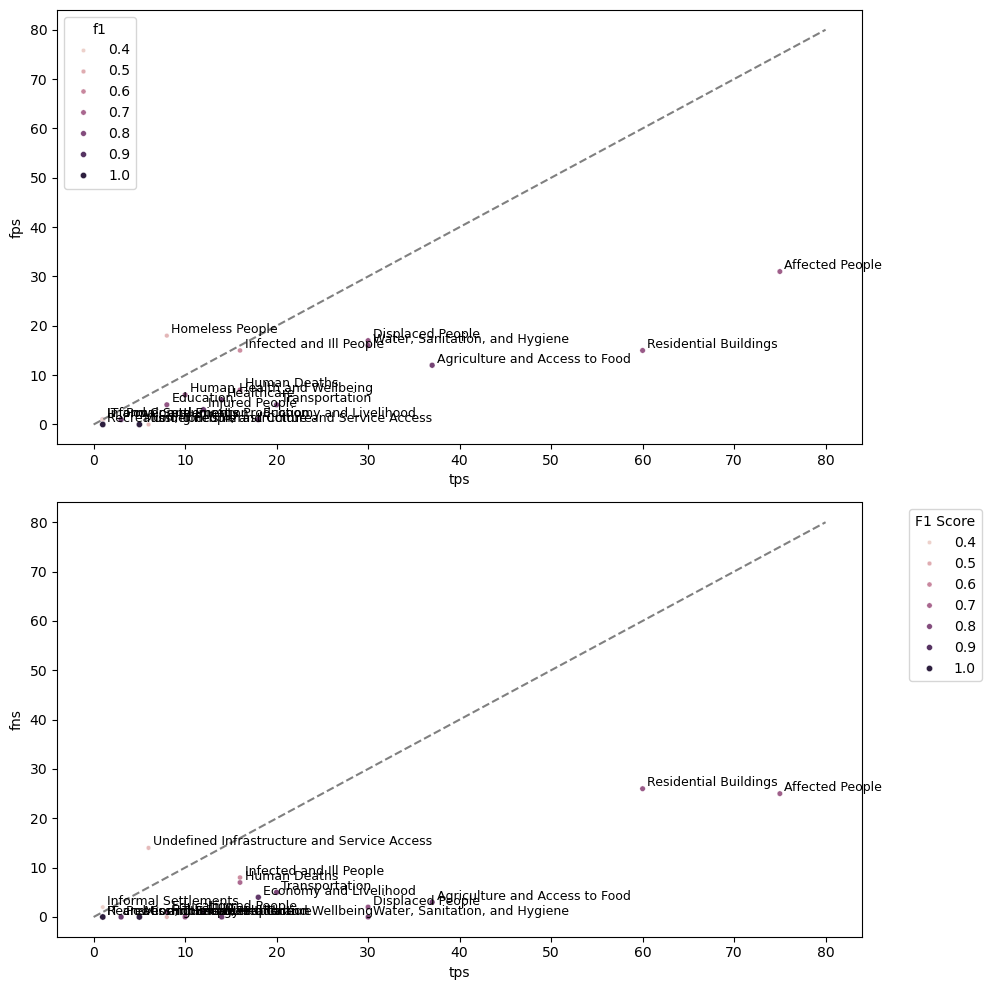

In [32]:
import seaborn as sns

fig, axes = plt.subplots(ncols=1, nrows=2, figsize=(10,10))
xkey = "tps"
ykeys = ["fps", "fns"]
for i, ykey in enumerate(ykeys):
    ax = axes[i]

    sns.scatterplot(
        ax=ax,
        data=f1_bs_by_subtype,
        x=xkey,
        y=ykey,
        hue="f1",
        size="f1",
        sizes=(10, 20),
        legend=True,
    )
    # add impact subtype text
    for i, row in f1_bs_by_subtype.iterrows():
        ax.text(row[xkey]+0.5, row[ykey]+0.5, row["impactSubtype"], fontsize=9)

    # add 1-1 line
    max_val = max(f1_bs_by_subtype[xkey].max(), f1_bs_by_subtype[ykey].max()) + 5
    ax.plot([0, max_val], [0, max_val], color="gray", linestyle="--")
    #ax.set_xlabel("Number of extracted impacts")
    #ax.set_ylabel("Number of labelled impacts")
    #ax.set_title("True Positives by Impact Subtype")
plt.legend(title="F1 Score", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [33]:
f1_bs_by_subtype

,impactSubtype,tps,n_ext,n_lab,fps,fns,f1,precision,recall,f1_low_err,f1_high_err,precision_low_err,precision_high_err,recall_low_err,recall_high_err
0,Affected People,75,106,100,31,25,0.728155,0.707547,0.750000,0.071745,0.064471,0.087560,0.084906,0.086735,0.083333
8,Residential Buildings,60,75,86,15,26,0.745342,0.800000,0.697674,0.083090,0.073372,0.096311,0.088889,0.097674,0.095019
20,Agriculture and Access to Food,37,49,40,12,3,0.831461,0.755102,0.925000,0.084855,0.073802,0.122449,0.117238,0.091667,0.075000
2,Displaced People,30,47,32,17,2,0.759494,0.638298,0.937500,0.120605,0.100971,0.148502,0.134429,0.093750,0.062500
16,"Water, Sanitation, and Hygiene",30,46,30,16,0,0.789474,0.652174,1.000000,0.132331,0.077996,0.141536,0.130435,0.103448,0.000000
15,Transportation,20,24,25,4,5,0.816327,0.833333,0.800000,0.134508,0.109599,0.166667,0.126667,0.163636,0.154545
11,Economy and Livelihood,18,19,22,1,4,0.878049,0.947368,0.818182,0.121292,0.099729,0.114035,0.052632,0.181818,0.138340
5,Human Deaths,16,23,23,7,7,0.695652,0.695652,0.695652,0.159067,0.127877,0.195652,0.173913,0.195652,0.179348
6,Infected and Ill People,16,31,24,15,8,0.581818,0.516129,0.666667,0.173655,0.139493,0.182796,0.173526,0.190476,0.185185
17,Healthcare,14,19,14,5,0,0.848485,0.736842,1.000000,0.181818,0.098884,0.210526,0.163158,0.214286,0.000000


In [34]:
f1_bs_by_appeal

,appealCode,tps,n_ext,n_lab,fps,fns,f1,precision,recall,f1_low_err,f1_high_err,precision_low_err,precision_high_err,recall_low_err,recall_high_err
10,MDRUG050,86,105,94,19,8,0.864322,0.819048,0.914894,0.053795,0.049140,0.076190,0.072041,0.060986,0.052848
15,MDRSD034,76,96,85,20,9,0.839779,0.791667,0.894118,0.060709,0.054958,0.081989,0.078333,0.068031,0.059371
16,MDRRW022,24,49,25,25,1,0.648649,0.489796,0.960000,0.141186,0.116783,0.142857,0.142857,0.096364,0.040000
12,MDRPK026,23,22,31,0,8,0.851852,1.000000,0.741935,0.131852,0.081481,0.142857,0.000000,0.161290,0.154616
7,MDRKE058,21,43,33,22,12,0.552632,0.488372,0.636364,0.146834,0.122067,0.147947,0.145774,0.169697,0.157773
3,MDRS2001,20,18,22,0,2,0.952381,1.000000,0.909091,0.102381,0.047619,0.150000,0.000000,0.136364,0.090909
8,MDRNG041,17,27,24,10,7,0.666667,0.629630,0.708333,0.177778,0.140351,0.185185,0.178063,0.184524,0.171667
11,MDRDZ011,17,25,20,8,3,0.755556,0.680000,0.850000,0.155556,0.124444,0.198519,0.171852,0.168182,0.150000
13,MDRCM039,16,24,17,8,1,0.780488,0.666667,0.941176,0.169377,0.132556,0.188406,0.173333,0.128676,0.058824
0,MDRCN006,15,17,15,2,0,0.937500,0.882353,1.000000,0.137500,0.062500,0.176471,0.117647,0.200000,0.000000


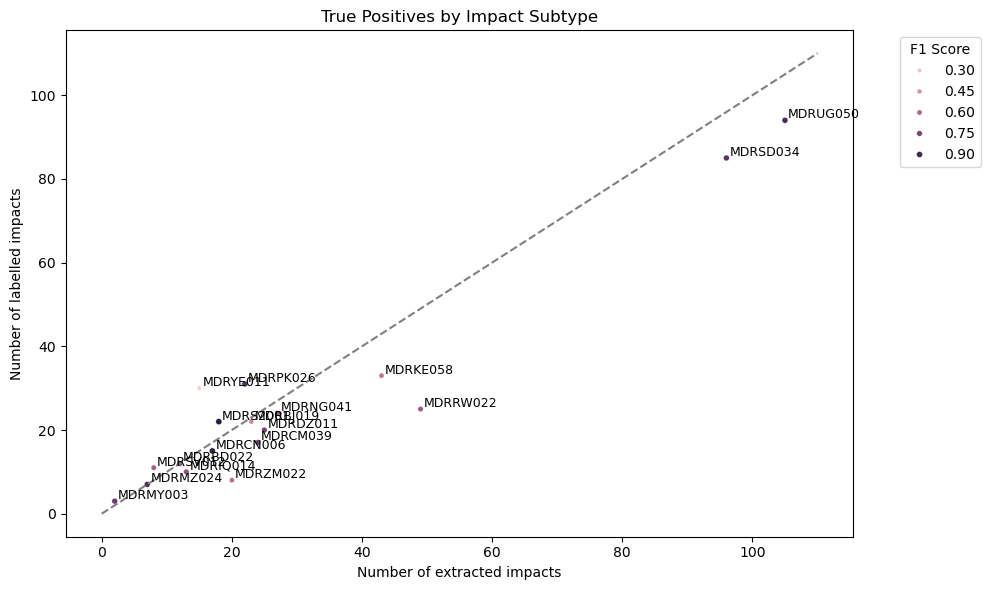

In [35]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(
    ax=ax,
    data=f1_bs_by_appeal,
    x="n_ext",
    y="n_lab",
    hue="f1",
    size="f1",
    sizes=(10, 20),
    legend=True,
)

# add impact subtype text
for i, row in f1_bs_by_appeal.iterrows():
    ax.text(row["n_ext"] + 0.5, row["n_lab"] + 0.5, row["appealCode"], fontsize=9)

# add 1-1 line
max_val = max(f1_bs_by_appeal["n_ext"].max(), f1_bs_by_appeal["n_lab"].max()) + 5
ax.plot([0, max_val], [0, max_val], color="gray", linestyle="--")
ax.set_xlabel("Number of extracted impacts")
ax.set_ylabel("Number of labelled impacts")
ax.set_title("True Positives by Impact Subtype")
plt.legend(title="F1 Score", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

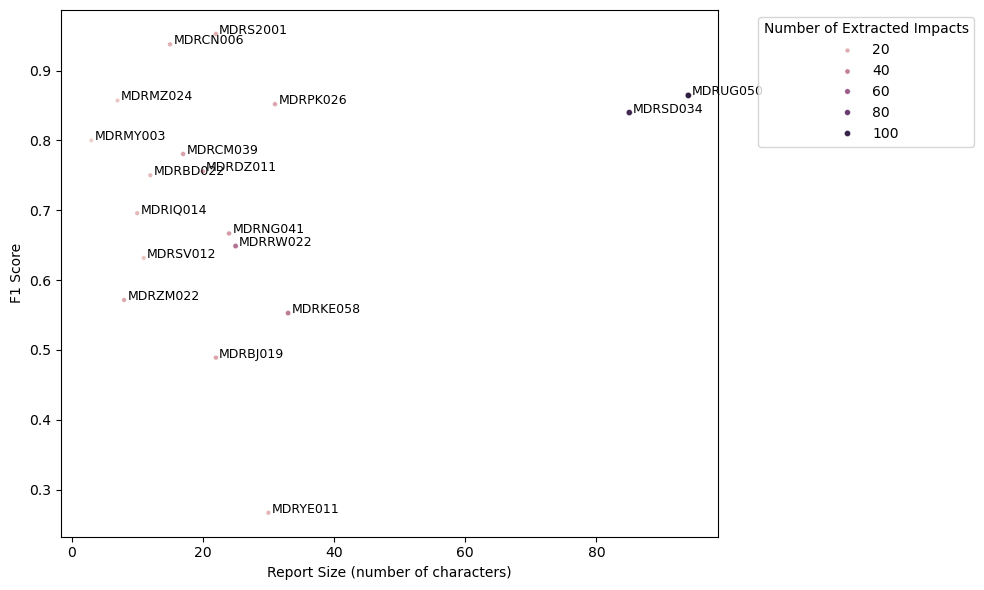

In [36]:
fig, ax = plt.subplots(figsize=(10, 6))
xkey="n_lab"
ykey="f1"
sns.scatterplot(
    ax=ax,
    data=f1_bs_by_appeal,
    x=xkey,
    y=ykey,
    hue="n_ext",
    size="n_ext",
    sizes=(10, 20),
    legend=True,
)

# add impact subtype text
for i, row in f1_bs_by_appeal.iterrows():
    ax.text(row[xkey] + 0.5, row[ykey], row["appealCode"], fontsize=9)

# add 1-1 line
#max_val = max(f1_bs_by_appeal[xkey].max(), f1_bs_by_appeal[ykey].max()) + 5
#ax.plot([0, max_val], [0, max_val], color="gray", linestyle="--")
ax.set_xlabel("Report Size (number of characters)")
ax.set_ylabel("F1 Score")
#ax.set_title("")
plt.legend(title="Number of Extracted Impacts", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

<Axes: xlabel='tps', ylabel='f1'>

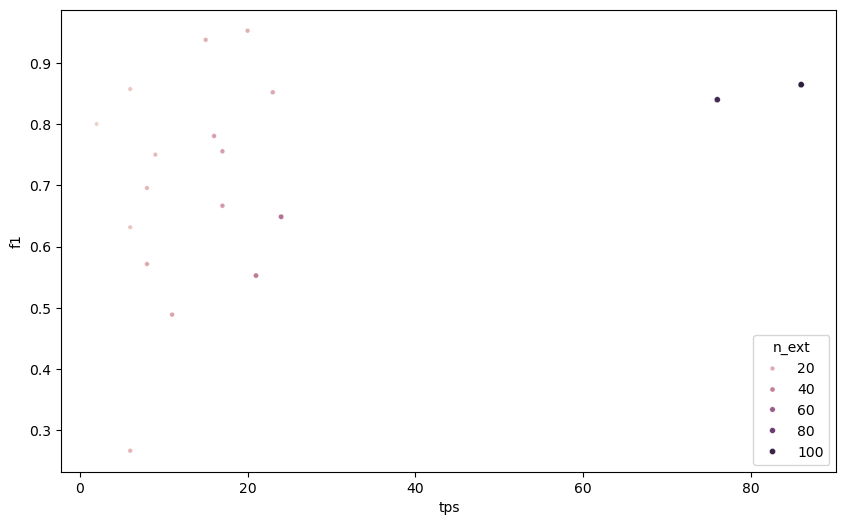

In [37]:
fig, ax = plt.subplots(figsize=(10, 6))
xkey = "tps"
ykey = "f1"
sns.scatterplot(
    ax=ax,
    data=f1_bs_by_appeal,
    x=xkey,
    y=ykey,
    hue="n_ext",
    size="n_ext",
    sizes=(10, 20),
    legend=True,
)

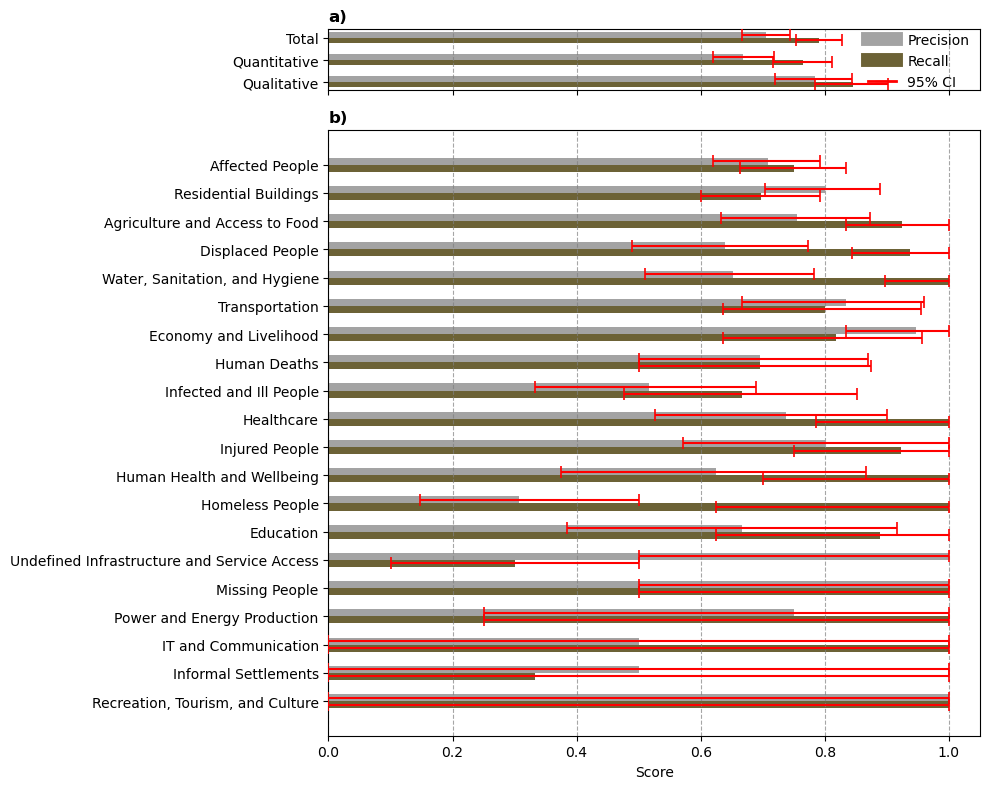

In [38]:
import textwrap
from click import group
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np

metrics = ["precision", "recall"]#"f1"
colors = ["#a3a3a3", "#6c6236", "#5e0eff"]  # distinct colors for each metric
group_key = "impactSubtype"


fig, ax = plt.subplots(2, 1, figsize=(10, 8), sharey=False, sharex=True, height_ratios=[1, 10])

# --- Function to plot grouped bars with error bars ---
def plot_metrics_with_errorbars(ax, df, x_col, metrics, colors):
    n_metrics = len(metrics)
    y_positions = np.arange(len(df))
    height = 0.25  # controls bar thickness
    spacing = 0.3  # space between metric groups

    for i, metric in enumerate(metrics):
        # compute shifted y positions for each metric
        offset = (i - (n_metrics - 1)/2) * height
        y_shifted = y_positions + offset

        val = df[f"{metric}"]
        lower = df[f"{metric}_low_err"]
        upper = df[f"{metric}_high_err"]

        ax.barh(
            y_shifted,
            val,
            height=height,
            color=colors[i],
            label=metric.capitalize()
        )

        # Add horizontal error bars
        xerr = [lower, upper]
        ax.errorbar(
            val, y_shifted, xerr=xerr,
            fmt='none', ecolor='red',
            elinewidth=1.5, capsize=4, capthick=1.2, zorder=5
        )

    ax.set_yticks(y_positions)
    ax.set_yticklabels(df[x_col])
    ax.invert_yaxis()
    ax.set_xlim(0, 1.05)  # adjust if scores in [0,1]

# --- Plot bottom panel (all-level metrics) ---
plot_metrics_with_errorbars(ax[0], f1_bs_all, "quanti", metrics, colors)

# --- Plot top panel (by-key metrics) ---
plot_metrics_with_errorbars(ax[1], f1_bs_by_subtype, group_key, metrics, colors)

# --- Labels ---
ax[1].set_xlabel("Score")
ax[0].set_ylabel("")
ax[1].set_ylabel("")

# --- Create combined legend handles ---
err_proxy = Line2D([0], [0], color='red', lw=2, marker='_', markersize=10, label='95% CI')
bars_proxy = [Line2D([0], [0], color=c, lw=10, label=m.capitalize()) for m, c in zip(metrics, colors)]

# --- Add legend ---
#ax[1].get_legend().remove()
ax[0].legend(handles=bars_proxy + [err_proxy], loc=(0.82, -0.08), frameon=False)#title="Metrics"

ax[0].set_title("a)", fontweight="bold", loc="left")
ax[1].set_title("b)", fontweight="bold", loc="left")

## add grids
ax[0].xaxis.grid(True, linestyle='--', which='major', color='grey', alpha=0.7)
ax[1].xaxis.grid(True, linestyle='--', which='major', color='grey', alpha=0.7)

plt.tight_layout()
plt.show()

fig.savefig(DATA_FIGURE / f"{'_'.join(metrics)}_vth-{value_error_th}_sth-{sim_th}_flt_{filename_match.replace(key, MODEL_NAMES_MAP[key])}.png", bbox_inches="tight", dpi=600)

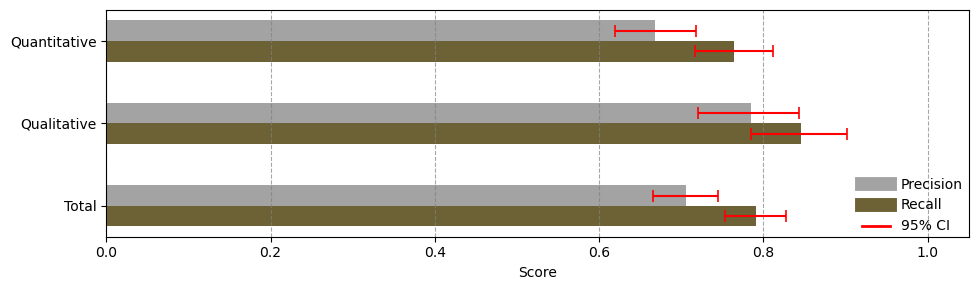

In [64]:
metrics = ["precision", "recall"]  # "f1"
colors = ["#a3a3a3", "#6c6236", "#5e0eff"]  # distinct colors for each metric
group_key = "impactSubtype"


fig, ax = plt.subplots(
    1, 1, figsize=(10, 3), sharey=False, sharex=False#, height_ratios=[1, 10]
)
ax = [ax]  # make ax a list for compatibility with plotting function
# --- Plot bottom panel (all-level metrics) ---
plot_metrics_with_errorbars(ax[0], f1_bs_all.set_index("quanti", drop=False).reindex(["Quantitative", "Qualitative", "Total"]), "quanti", metrics, colors)

# --- Plot top panel (by-key metrics) ---
#plot_metrics_with_errorbars(ax[1], f1_bs_by_subtype, group_key, metrics, colors)

# --- Labels ---
ax[0].set_xlabel("Score")
ax[0].set_ylabel("")

# --- Create combined legend handles ---
err_proxy = Line2D(
    [0], [0], color="red", lw=2, marker="_", markersize=10, label="95% CI"
)
bars_proxy = [
    Line2D([0], [0], color=c, lw=10, label=m.capitalize())
    for m, c in zip(metrics, colors)
]

# --- Add legend ---
# ax[1].get_legend().remove()
ax[0].legend(
    handles=bars_proxy + [err_proxy], loc=(0.87, -0.01), frameon=False
)  # title="Metrics"

#ax[0].set_title("a)", fontweight="bold", loc="left")
#ax[1].set_title("b)", fontweight="bold", loc="left")

## add grids
ax[0].xaxis.grid(True, linestyle="--", which="major", color="grey", alpha=0.7)
#ax[1].xaxis.grid(True, linestyle="--", which="major", color="grey", alpha=0.7)

plt.tight_layout()
plt.show()

fig.savefig(
    DATA_FIGURE
    / f"precision_recall_EGU26.png",
    bbox_inches="tight",
    dpi=600,
)

In [65]:
f1_bs_all

,quanti,n_ext,n_lab,tps,fps,fns,f1,precision,recall,f1_low_err,f1_high_err,precision_low_err,precision_high_err,recall_low_err,recall_high_err
0,Total,526,469,371,155,98,0.745729,0.705323,0.791045,0.031002,0.029541,0.039286,0.038819,0.037232,0.036619
0,Quantitative,359,314,240,119,74,0.713224,0.668524,0.764331,0.039411,0.038937,0.049476,0.049786,0.047292,0.047172
0,Qualitative,167,155,131,36,24,0.813665,0.784431,0.845161,0.049911,0.042623,0.064199,0.059499,0.060351,0.056154


In [41]:
un_matched = matched_df_filter1[(matched_df_filter1["match_sim"] <= sim_th)]
un_matched_quali = un_matched[(matched_df_filter1["quanti"] == "quali")]
un_matched_quanti = un_matched[(matched_df_filter1["quanti"] == "quanti")]


/Users/lseverino/miniforge3/envs/ifrc_llm_311/lib/python3.11/site-packages/geopandas/geodataframe.py:1896: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  result = super().__getitem__(key)
/Users/lseverino/miniforge3/envs/ifrc_llm_311/lib/python3.11/site-packages/geopandas/geodataframe.py:1896: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  result = super().__getitem__(key)


In [42]:
un_matched_quali.impactSubtype.value_counts()

impactSubtype
Water, Sanitation, and Hygiene    7
Displaced People                  5
Affected People                   5
Homeless People                   4
Agriculture and Access to Food    4
Human Health and Wellbeing        4
Economy and Livelihood            3
Residential Buildings             2
Missing People                    2
Education                         2
Name: count, dtype: int64

In [43]:
un_matched_quanti.impactSubtype.value_counts()

impactSubtype
Human Deaths                      2
Displaced People                  1
Agriculture and Access to Food    1
Transportation                    1
Name: count, dtype: int64

In [44]:
un_matched.impactSubtype.value_counts()

impactSubtype
Water, Sanitation, and Hygiene    7
Displaced People                  6
Agriculture and Access to Food    5
Affected People                   5
Homeless People                   4
Human Health and Wellbeing        4
Economy and Livelihood            3
Residential Buildings             2
Missing People                    2
Education                         2
Human Deaths                      2
Transportation                    1
Name: count, dtype: int64

In [45]:
un_matched.appealCode.value_counts()

appealCode
MDRYE011    10
MDRIQ014     8
MDRBD022     6
MDRPK026     6
MDRKE058     4
MDRSV012     3
MDRNG041     2
MDRSD034     2
MDRMY003     1
MDRS2001     1
Name: count, dtype: int64

In [46]:
labelled_df_filter[labelled_df_filter["appealCode"] == "MDRZM022"]

,reportDate,impactSubtype,impactValue,impactUnit,impactValuePrecision,impactValueMin,impactValueMax,annotation,country,location,...,flag_geocoding_osm,locationOsm,locationPolygon,iso3_code,gaul0_code,gaul1_code,gaul2_code,impactValueApprox,flag_pop_cntry,geometry
170,2024-04-02,Affected People,5000000.0,people,approx,NaN,NaN,['Page 1 / 21 DREF Operation Zambia Drought 20...,['Zambia'],"['North-Western province', 'Southern province'...",...,0.0,"['North-Western Province', 'Southern Province'...","['North-Western', 'Northern', 'Southern', 'Eas...",['ZMB'],[168.0],"[1717.0, 1718.0, 1719.0, 1713.0, 1720.0, 1711....","[nan, 106584.0]",NaN,False,"MULTIPOLYGON (((24.08784 -10.90128, 24.09459 -..."
171,2024-04-02,Agriculture and Access to Food,10000.0,km**2 of crop production and forestry,approx,NaN,NaN,['Page 1 / 21 DREF Operation Zambia Drought 20...,['Zambia'],"['North-Western province', 'Southern province'...",...,0.0,"['North-Western Province', 'Southern Province'...","['North-Western', 'Northern', 'Southern', 'Eas...",['ZMB'],[168.0],"[1717.0, 1718.0, 1719.0, 1713.0, 1720.0, 1711....","[nan, 106584.0]",NaN,False,"MULTIPOLYGON (((24.08784 -10.90128, 24.09459 -..."
172,2024-04-02,Agriculture and Access to Food,NaN,null,approx,NaN,NaN,['Page 1 / 21 DREF Operation Zambia Drought 20...,['Zambia'],"['North-Western province', 'Southern province'...",...,0.0,"['North-Western Province', 'Southern Province'...","['North-Western', 'Northern', 'Southern', 'Eas...",['ZMB'],[168.0],"[1717.0, 1718.0, 1719.0, 1713.0, 1720.0, 1711....","[nan, 106584.0]",NaN,False,"MULTIPOLYGON (((24.08784 -10.90128, 24.09459 -..."
173,2024-04-02,"Water, Sanitation, and Hygiene",NaN,null,approx,NaN,NaN,['Page 1 / 21 DREF Operation Zambia Drought 20...,['Zambia'],"['North-Western province', 'Southern province'...",...,0.0,"['North-Western Province', 'Southern Province'...","['North-Western', 'Northern', 'Southern', 'Eas...",['ZMB'],[168.0],"[1717.0, 1718.0, 1719.0, 1713.0, 1720.0, 1711....","[nan, 106584.0]",NaN,False,"MULTIPOLYGON (((24.08784 -10.90128, 24.09459 -..."
174,2024-04-02,Economy and Livelihood,NaN,null,approx,NaN,NaN,['Page 1 / 21 DREF Operation Zambia Drought 20...,['Zambia'],"['North-Western province', 'Southern province'...",...,0.0,"['North-Western Province', 'Southern Province'...","['North-Western', 'Northern', 'Southern', 'Eas...",['ZMB'],[168.0],"[1717.0, 1718.0, 1719.0, 1713.0, 1720.0, 1711....","[nan, 106584.0]",NaN,False,"MULTIPOLYGON (((24.08784 -10.90128, 24.09459 -..."
175,2024-04-02,Agriculture and Access to Food,2040000.0,people,approx,NaN,NaN,['Page 1 / 21 DREF Operation Zambia Drought 20...,['Zambia'],"['North-Western province', 'Southern province'...",...,0.0,"['North-Western Province', 'Southern Province'...","['North-Western', 'Northern', 'Southern', 'Eas...",['ZMB'],[168.0],"[1717.0, 1718.0, 1719.0, 1713.0, 1720.0, 1711....","[nan, 106584.0]",NaN,False,"MULTIPOLYGON (((24.08784 -10.90128, 24.09459 -..."
176,2024-04-02,Affected People,546139.0,people,exact,NaN,NaN,['Page 1 / 21 DREF Operation Zambia Drought 20...,['Zambia'],"['Kalabo district', 'Senanga district', 'Sikon...",...,0.0,"['Kalabo', 'Senanga', 'Sikongo', 'Shangombo', ...","['Kalabo', 'Senanga', 'Sikongo', 'Shangombo', ...",['ZMB'],[168.0],"[1720.0, 1717.0]","[106631.0, 106642.0, 106645.0, 106644.0, 10664...",NaN,False,"MULTIPOLYGON (((22.04535 -14.02934, 22.0482 -1..."
177,2024-04-02,Human Health and Wellbeing,NaN,null,approx,NaN,NaN,['Page 1 / 21 DREF Operation Zambia Drought 20...,['Zambia'],"['North-Western province', 'Southern province'...",...,0.0,"['North-Western Province', 'Southern Province'...","['North-Western', 'Northern', 'Southern', 'Eas...",['ZMB'],[168.0],"[1717.0, 1718.0, 1719.0, 1713.0, 1720.0, 1711....","[nan, 106584.0]",NaN,False,"MULTIPOLYGON (((24.08784 -10.90128, 24.09459 -..."


In [47]:
extracted_df_filter[extracted_df_filter["appealCode"] == "MDRZM022"]

,impactSubtype,impactValue,impactValueMin,impactValueMax,impactValuePrecision,impactUnit,valueAnnotation,valid_errors_impactValue,location,locationAnnotation,...,locationOsm,locationPolygon,iso3_code,gaul0_code,gaul1_code,gaul2_code,impactValueApprox,flag_pop_cntry,geometry,reportSize
511,Affected People,5000000.0,NaN,NaN,exact,people,"['People Affected: 5,000,000 people']",0,[],"['People Affected: 5,000,000 people']",...,['Zambia'],['Zambia'],['ZMB'],[168.0],[nan],[nan],NaN,False,"MULTIPOLYGON (((30.74001 -8.34001, 31.15775 -8...",14555
514,Affected People,5000000.0,NaN,NaN,exact,people,"['1 million households have been affected, and...",0,"['Southern Province', 'Central', 'Eastern', 'N...",['The whole Southern half of Zambia is experie...,...,"['Southern Province', 'Central Province', 'Eas...","['Northern', 'Southern', 'Central', 'Eastern',...",['ZMB'],[168.0],"[1718.0, 1719.0, 1711.0, 1713.0, 1720.0, 1717....","[nan, 106584.0]",NaN,False,"MULTIPOLYGON (((30.79415 -8.2742, 30.79508 -8....",14555
515,Agriculture and Access to Food,10000.0,NaN,NaN,exact,km**2 of crop production and forestry,['1 million hectors of maize field affected ou...,0,"['Southern Province', 'Central', 'Eastern', 'N...",['The current drought has affected 8 provinces...,...,"['Southern Province', 'Central Province', 'Eas...","['Northern', 'Southern', 'Central', 'Eastern',...",['ZMB'],[168.0],"[1718.0, 1719.0, 1711.0, 1713.0, 1720.0, 1717....","[nan, 106584.0, 106624.0, 106625.0, 106631.0, ...",NaN,False,"MULTIPOLYGON (((30.79415 -8.2742, 30.79508 -8....",14555
516,Agriculture and Access to Food,22000.0,NaN,NaN,exact,km**2,['1 million hectors of maize field affected ou...,0,"['Southern Province', 'Central', 'Eastern', 'N...",['The whole Southern half of Zambia is experie...,...,"['Southern Province', 'Central Province', 'Eas...","['Northern', 'Southern', 'Central', 'Eastern',...",['ZMB'],[168.0],"[1718.0, 1719.0, 1711.0, 1713.0, 1720.0, 1717....","[nan, 106584.0, 106624.0, 106625.0, 106631.0, ...",NaN,False,"MULTIPOLYGON (((30.79415 -8.2742, 30.79508 -8....",14555
517,Agriculture and Access to Food,5000000.0,NaN,NaN,exact,people,['The whole Southern half of Zambia is experie...,0,"['The whole Southern half of Zambia', 'Zambia']",['The whole Southern half of Zambia is experie...,...,['Zambia'],['Zambia'],['ZMB'],[168.0],[nan],[nan],NaN,False,"MULTIPOLYGON (((30.74001 -8.34001, 31.15775 -8...",14555
518,Affected People,2040000.0,NaN,NaN,approx,people,['The situation has come at the time when the ...,0,[],['The situation has come at the time when the ...,...,['Zambia'],['Zambia'],['ZMB'],[168.0],[nan],[nan],NaN,False,"MULTIPOLYGON (((30.74001 -8.34001, 31.15775 -8...",14555
519,Affected People,546139.0,NaN,NaN,exact,people,"['Among the most affected districts, Kalabo, S...",0,"['Kalabo', 'Senanga', 'Sikongo', 'Shangombo', ...","['Among the most affected districts, Kalabo, S...",...,"['Kalabo', 'Senanga', 'Sikongo', 'Shangombo', ...","['Kalabo', 'Senanga', 'Sikongo', 'Shangombo', ...",['ZMB'],[168.0],"[1720.0, 1717.0]","[106631.0, 106642.0, 106645.0, 106644.0, 10664...",NaN,False,"MULTIPOLYGON (((22.04535 -14.02934, 22.0482 -1...",14555
520,Affected People,247390.0,NaN,NaN,exact,people,"['Lunga, Milengi, Rufunsa, Lupososhi and Mwans...",0,"['Lunga', 'Milengi', 'Rufunsa', 'Lupososhi', '...","['Lunga, Milengi, Rufunsa, Lupososhi and Mwans...",...,"['Lunga District', 'Zambia', 'Rufunsa', 'Lupos...","['Luapula', 'Zambia', 'Rufunsa', 'Northern', '...",['ZMB'],[168.0],"[1714.0, nan, 1715.0, 1718.0, 1719.0]","[nan, 106585.0, 106575.0]",NaN,False,"MULTIPOLYGON (((29.37184 -8.72326, 29.37003 -8...",14555
521,Agriculture and Access to Food,10000.0,NaN,NaN,exact,km**2,['One (1) million households (five (5) million...,0,"['Southern Province', 'Central', 'Eastern', 'N...",['The whole Southern half of Zambia is experie...,...,"['Southern Province', 'Central Province', 'Eas...","['Northern', 'Southern', 'Central', 'Eastern',...",['ZMB'],[168.0],"[1718.0, 1719.0, 1711.0, 1713

In [48]:
un_matched[un_matched["appealCode"] == "MDRZM022"]["impactValue_sim"].max()

nan

In [49]:
print_match(un_matched[un_matched["appealCode"]=="MDRRW022"])

,appealCode,impactSubtype,impactSubtype_matched,impactValue,impactValue_matched,impactUnit,impactUnit_matched,location,location_matched,locationPolygon,...,startYear_sim,startMonth_sim,startDay_sim,endYear_sim,endMonth_sim,endDay_sim,hazards_sim,match_sim,valueAnnotation,annotation_matched


In [50]:
un_matched[un_matched["impactSubtype"] == "Economy and Livelihood"][["location","location_matched","locationPolygon", "locationPolygon_matched", "locationOsm", "locationOsm_matched"]]

,location,location_matched,locationPolygon,locationPolygon_matched,locationOsm,locationOsm_matched
15,"['Kurigram', 'Gaibandha', 'Lalmonirhat', 'Chat...","['Kurigram district', 'Gaibandha district', 'L...","['Rangpur', 'Gaibandha', 'Chittagong', 'Rangam...","['Rangpur', 'Gaibandha', 'Chittagong', 'Rangam...","['Kurigram District', 'Gaibandha', 'Lalmonirha...","['Kurigram District', 'Gaibandha', 'Lalmonirha..."
16,"['Kurigram', 'Gaibandha', 'Lalmonirhat', 'Chat...","['Gaddimari area', 'Lalmonirhats Hatibandha']","['Rangpur', 'Gaibandha', 'Chittagong', 'Rangam...","['Bangladesh', 'Gaibandha']","['Kurigram District', 'Gaibandha', 'Lalmonirha...","['Bangladesh', 'Lalmonirhat - Patgram Hwy']"
279,"['coastal area', 'Clarendon', 'St. Elizabeth',...",[],"['Clarendon', 'Jamaica', 'Saint Joseph', 'Chri...",['Jamaica'],"['Clarendon', 'Jamaica', 'St. Elizabeths', 'Ma...",['Jamaica']


In [51]:
print_match(un_matched[un_matched["impactSubtype"]=="Economy and Livelihood"])

,appealCode,impactSubtype,impactSubtype_matched,impactValue,impactValue_matched,impactUnit,impactUnit_matched,location,location_matched,locationPolygon,...,startYear_sim,startMonth_sim,startDay_sim,endYear_sim,endMonth_sim,endDay_sim,hazards_sim,match_sim,valueAnnotation,annotation_matched
15,MDRBD022,Economy and Livelihood,Undefined Infrastructure and Service Access,NaN,NaN,null,null,"['Kurigram', 'Gaibandha', 'Lalmonirhat', 'Chat...","['Kurigram district', 'Gaibandha district', 'L...","['Rangpur', 'Gaibandha', 'Chittagong', 'Rangam...",...,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.472222,['While the monsoon season normally brings ann...,['It is also reported that embankments have be...
16,MDRBD022,Economy and Livelihood,Undefined Infrastructure and Service Access,NaN,NaN,null,null,"['Kurigram', 'Gaibandha', 'Lalmonirhat', 'Chat...","['Gaddimari area', 'Lalmonirhats Hatibandha']","['Rangpur', 'Gaibandha', 'Chittagong', 'Rangam...",...,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.341982,['While the monsoon season normally brings ann...,['of union affected 776 Emergency Plan of Acti...
279,MDRS2001,Economy and Livelihood,Infected and Ill People,NaN,NaN,null,null,"['coastal area', 'Clarendon', 'St. Elizabeth',...",[],"['Clarendon', 'Jamaica', 'Saint Joseph', 'Chri...",...,1.0,1.0,1.0,1.0,1.0,1.0,0.5,0.495630,['The economic toll of Hurricane Beryl is subs...,"['This displacement, combined with damaged wat..."


In [52]:
un_matched.appealCode.value_counts()

appealCode
MDRYE011    10
MDRIQ014     8
MDRBD022     6
MDRPK026     6
MDRKE058     4
MDRSV012     3
MDRNG041     2
MDRSD034     2
MDRMY003     1
MDRS2001     1
Name: count, dtype: int64

In [53]:
labelled_df[labelled_df["appealCode"] == "MDRRW022"]

,reportDate,impactSubtype,impactValue,impactUnit,impactValuePrecision,impactValueMin,impactValueMax,annotation,country,location,...,flag_geocoding_osm,locationOsm,locationPolygon,iso3_code,gaul0_code,gaul1_code,gaul2_code,impactValueApprox,flag_pop_cntry,geometry
450,2024-09-05,Affected People,60000.0,people,exact,NaN,NaN,['DREF Final Report Rwanda - Floods and Landsl...,['Rwanda'],[],...,0.0,['Rwanda'],['Rwanda'],['RWA'],[152.0],[nan],[nan],NaN,False,"MULTIPOLYGON (((30.4191 -1.13466, 30.81613 -1...."
451,2024-09-05,Affected People,51905.0,people,exact,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,0.0,['Rwanda'],['Rwanda'],['RWA'],[152.0],[nan],[nan],NaN,False,"MULTIPOLYGON (((30.4191 -1.13466, 30.81613 -1...."
452,2024-09-05,Human Deaths,137.0,people,exact,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,0.0,['Rwanda'],['Rwanda'],['RWA'],[152.0],[nan],[nan],NaN,False,"MULTIPOLYGON (((30.4191 -1.13466, 30.81613 -1...."
453,2024-09-05,Residential Buildings,5472.0,homes,exact,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,0.0,['Rwanda'],['Rwanda'],['RWA'],[152.0],[nan],[nan],NaN,False,"MULTIPOLYGON (((30.4191 -1.13466, 30.81613 -1...."
454,2024-09-05,"Water, Sanitation, and Hygiene",NaN,null,approx,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,0.0,['Rwanda'],['Rwanda'],['RWA'],[152.0],[nan],[nan],NaN,False,"MULTIPOLYGON (((30.4191 -1.13466, 30.81613 -1...."
455,2024-09-05,Transportation,NaN,null,approx,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,0.0,['Rwanda'],['Rwanda'],['RWA'],[152.0],[nan],[nan],NaN,False,"MULTIPOLYGON (((30.4191 -1.13466, 30.81613 -1...."
456,2024-09-05,Agriculture and Access to Food,10.0,km**2 of crop production and forestry,approx,10.0,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,0.0,['Rwanda'],['Rwanda'],['RWA'],[152.0],[nan],[nan],NaN,False,"MULTIPOLYGON (((30.4191 -1.13466, 30.81613 -1...."
457,2024-09-05,Agriculture and Access to Food,NaN,null,approx,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,0.0,['Rwanda'],['Rwanda'],['RWA'],[152.0],[nan],[nan],NaN,False,"MULTIPOLYGON (((30.4191 -1.13466, 30.81613 -1...."
458,2024-09-05,Displaced People,38000.0,people,approx,38000.0,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,0.0,['Rwanda'],['Rwanda'],['RWA'],[152.0],[nan],[nan],NaN,False,"MULTIPOLYGON (((30.4191 -1.13466, 30.81613 -1...."
459,2024-09-05,Residential Buildings,4933.0,homes,approx,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],"['Rubavu', 'Nyabihu', 'Ngororero', 'Karongi', ...",...,6.0,"['Rubavu', 'Nyabihu', 'Ngororero', 'Karongi', ...",['Iburengerazuba'],['RWA'],[152.0],[1557.0],[nan],NaN,False,"MULTIPOLYGON (((29.49935 -1.56369, 29.49944 -1..."


In [54]:
extracted_df[extracted_df["appealCode"] == "MDRRW022"]

,impactSubtype,impactValue,impactValueMin,impactValueMax,impactValuePrecision,impactUnit,valueAnnotation,valid_errors_impactValue,location,locationAnnotation,...,locationOsm,locationPolygon,iso3_code,gaul0_code,gaul1_code,gaul2_code,impactValueApprox,flag_pop_cntry,geometry,reportSize
268,Affected People,60000.000000,NaN,NaN,exact,people,"['People Affected: 60,000 people']",0,"['North Province', 'South Province', 'West Pro...","['People Affected: 60,000 people']",...,['Rwanda'],['Rwanda'],['RWA'],[152.0],[nan],[nan],NaN,False,"MULTIPOLYGON (((30.4191 -1.13466, 30.81613 -1....",12484
269,Targeted People,49485.000000,NaN,NaN,exact,people,"['People Targeted: 49,485 people']",0,"['North Province', 'South Province', 'West Pro...","['Targeted Areas: North Province, South Provin...",...,['Rwanda'],['Rwanda'],['RWA'],[152.0],[nan],[nan],NaN,False,"MULTIPOLYGON (((30.4191 -1.13466, 30.81613 -1....",12484
270,DREF Allocation & Funding requirements,532435.569755,NaN,NaN,exact,EUR,"['Total DREF Allocation: CHF 499,957']",0,[],"['Total DREF Allocation: CHF 499,957']",...,['Rwanda'],['Rwanda'],['RWA'],[152.0],[nan],[nan],NaN,False,"MULTIPOLYGON (((30.4191 -1.13466, 30.81613 -1....",12484
271,Affected People,51905.000000,NaN,NaN,exact,people,"['Overall, 14 districts experienced flooding a...",0,"['Western Province', 'Northern Province', 'Sou...","['Overall, 14 districts experienced flooding a...",...,"['Western Province', 'Northern Province', 'Sou...","['Iburengerazuba', 'Amajyaruguru', 'Amajyepfo']",['RWA'],[152.0],"[1557.0, 1554.0, 1555.0]",[nan],NaN,False,"MULTIPOLYGON (((29.49935 -1.56369, 29.49944 -1...",12484
272,Human Deaths,137.000000,NaN,NaN,exact,people,"['A total of 137 people died, and 5,472 houses...",0,[],"['A total of 137 people died, and 5,472 houses...",...,['Rwanda'],['Rwanda'],['RWA'],[152.0],[nan],[nan],NaN,False,"MULTIPOLYGON (((30.4191 -1.13466, 30.81613 -1....",12484
273,Homeless People,51905.000000,NaN,NaN,exact,people,"['Overall, 14 districts experienced flooding a...",0,"['Western Province', 'Northern Province', 'Sou...","['From 1 to 6 May, Rwanda experienced continuo...",...,"['Western Province', 'Northern Province', 'Sou...","['Iburengerazuba', 'Amajyaruguru', 'Amajyepfo']",['RWA'],[152.0],"[1557.0, 1554.0, 1555.0]",[nan],NaN,False,"MULTIPOLYGON (((29.49935 -1.56369, 29.49944 -1...",12484
274,Displaced People,51905.000000,NaN,NaN,exact,people,['Those affected were gathered together in IDP...,0,"['Western Province', 'Northern Province', 'Sou...",['According to assessments carried out by the ...,...,"['Western Province', 'Northern Province', 'Sou...","['Iburengerazuba', 'Amajyaruguru', 'Amajyepfo']",['RWA'],[152.0],"[1557.0, 1554.0, 1555.0]",[nan],NaN,False,"MULTIPOLYGON (((29.49935 -1.56369, 29.49944 -1...",12484
275,Residential Buildings,5472.000000,NaN,NaN,exact,homes,"['A total of 137 people died, and 5,472 houses...",0,"['Western Province', 'Northern Province', 'Sou...","['From 1 to 6 May, Rwanda experienced continuo...",...,"['Western Province', 'Northern Province', 'Sou...","['Iburengerazuba', 'Amajyaruguru', 'Amajyepfo']",['RWA'],[152.0],"[1557.0, 1554.0, 1555.0]",[nan],NaN,False,"MULTIPOLYGON (((29.49935 -1.56369, 29.49944 -1...",12484
276,Displaced People,38000.000000,NaN,NaN,exact,people,['Information reported by branches on 3rd stat...,0,[],['Information reported by branches on 3rd stat...,...,['Rwanda'],['Rwanda'],['RWA'],[152.0],[nan],[nan],NaN,False,"MULTIPOLYGON (((30.4191 -1.13466, 30.81613 -1....",12484
277,Homeless People,38420.000000,NaN,NaN,exact,people,['Information reported by branches on 3rd stat...,0,[],['Information reported by branches on 3rd stat...,...,['Rwanda'],['Rwanda'],['RWA'],[152.0],[nan],[nan],NaN,False,"MULTIPOLYGON (((30.4191 -1.13466, 30.81613 -1....",12484


In [55]:
cat = "Healthcare"
ext_df = extracted_df_filter[extracted_df_filter["impactSubtype"]==cat]
lab_df = labelled_df_filter[labelled_df_filter["impactSubtype"]==cat]
m_df1 = matched_df_filter1[matched_df_filter1["impactSubtype"]==cat]
m_df2 = matched_df_filter2[matched_df_filter2["impactSubtype"]==cat]
make_coverage_accuracy_df(ext_df, lab_df, m_df2, group_key="impactSubtype", group_keys=[cat]).reset_index(drop=False, names=["impactSubtype"])

,impactSubtype,nb labelled,nb extracted,coverage,true_positives,false_negatives,false_positives,precision,recall,f1,quanti
0,Healthcare,7,9,128.571429,7,0,2,0.777778,1.0,0.875000,quanti
1,Healthcare,7,10,142.857143,7,0,3,0.700000,1.0,0.823529,quali


In [56]:
print_match(m_df2)

,appealCode,impactSubtype,impactSubtype_matched,impactValue,impactValue_matched,impactUnit,impactUnit_matched,location,location_matched,locationPolygon,...,startYear_sim,startMonth_sim,startDay_sim,endYear_sim,endMonth_sim,endDay_sim,hazards_sim,match_sim,valueAnnotation,annotation_matched
130,MDRKE058,Healthcare,Healthcare,7.0,7.0,healthcare structures,healthcare structures,[],"['Lake Victoria Basin', 'Highlands West of the...",['Kenya'],...,1.0,1.0,0.0,0.0,0.0,0.0,0.577350,0.930685,['The economic activities of the areas have be...,['October November December short rains season...
136,MDRKE058,Healthcare,Healthcare,59.0,59.0,healthcare structures,healthcare structures,[],[],['Kenya'],...,1.0,1.0,1.0,0.0,0.0,1.0,0.707107,0.962123,['Health facilities 59 7'],['October November December short rains season...
238,MDRRW022,Healthcare,Healthcare,8.0,8.0,healthcare structures,healthcare structures,[],[],['Rwanda'],...,1.0,1.0,0.0,0.0,0.0,0.0,0.707107,0.935807,['6 Water Treatment Plants flooded and not fun...,"['From 1 to 6 May, Rwanda experienced continuo..."
242,MDRRW022,Healthcare,Healthcare,14.0,14.0,healthcare structures,healthcare structures,['Rutsiro'],['Rutsiro'],['Iburengerazuba'],...,1.0,1.0,0.0,0.0,0.0,0.0,0.707107,0.935807,"['Additionlly,14 health centres in Rutsiro wer...","['From 1 to 6 May, Rwanda experienced continuo..."
284,MDRSD034,Healthcare,Healthcare,80.0,80.0,healthcare structures,healthcare structures,[],[],['Sudan'],...,0.0,0.0,1.0,0.0,0.0,1.0,0.577350,0.904369,['The conflict disrupted the operations of 80%...,['The conflict disrupted the operations of 80%...
351,MDRSD034,Healthcare,Healthcare,1.0,1.0,healthcare structures,healthcare structures,"['Tokar city, Red Sea State']",['Tokar'],['Sudan'],...,1.0,1.0,1.0,0.0,1.0,1.0,0.707107,0.896722,['The city’s hospital has been severely affect...,"['- In Tokar city, Red Sea State, the situatio..."
437,MDRUG050,Healthcare,Healthcare,3.0,3.0,healthcare structures,healthcare structures,"['Bukedea district', 'Kolir Sub County']",['Kolir Sub County'],"['Bukedea', 'Eastern']",...,1.0,1.0,0.0,0.0,0.0,1.0,1.000000,0.883810,['This resulted in the destruction of three he...,"['Following heavy rainfall, a rise in the wate..."
205,MDRPK026,Healthcare,Healthcare,NaN,NaN,null,null,"['Badin', 'Sohbatpur', 'Chitral']",[],"['Badin', 'Sohbatpur', 'Chitral Lower', 'Chitr...",...,1.0,0.0,1.0,0.0,0.0,0.0,0.000000,0.615474,"['Additionally, the stagnant water in low-lyin...","['Additionally, the stagnant water in low-lyin..."
206,MDRPK026,Healthcare,Healthcare,NaN,NaN,null,null,"['Badin', 'Sohbatpur', 'Chitral']","['Badin', 'Sindh']","['Badin', 'Sohbatpur', 'Chitral Lower', 'Chitr...",...,1.0,0.0,1.0,0.0,0.0,0.0,1.000000,0.702423,"['Additionally, the stagnant water in low-lyin...","['In response, PRCS successfully deployed a Mo..."
249,MDRRW022,Healthcare,Healthcare,NaN,NaN,null,null,"['Rubavu', 'Nyarugenge', 'Cyondo', 'Nyagatare'...","['Muhanga', 'Ngororero', 'Mukamira', 'Rubenger...","['Iburengerazuba', 'Nyarugenge', 'Rwanda', 'Ny...",...,1.0,1.0,1.0,1.0,0.0,0.0,1.000000,0.941749,['6 Water Treatment Plants flooded and not fun...,"['From 1 to 6 May, Rwanda experienced continuo..."


In [57]:
print_match(matched_df_filter1[(matched_df_filter1["impactSubtype_sim"] <= 0.8)]).value_counts("impactSubtype")

impactSubtype
Displaced People                  12
Homeless People                   10
Affected People                    9
Water, Sanitation, and Hygiene     9
Agriculture and Access to Food     5
Human Health and Wellbeing         5
Economy and Livelihood             4
Human Deaths                       3
Residential Buildings              3
Education                          2
Missing People                     2
Infected and Ill People            1
Injured People                     1
Transportation                     1
Name: count, dtype: int64

In [58]:
un_matched = matched_df_filter1[(matched_df_filter1["match_sim"] <= 0.5) & (matched_df_filter1["quanti"] == "quali")]
for groupid, group in un_matched.groupby("impactSubtype"):
    print(groupid)
    print(group.value_counts("impactSubtype_matched"))

Affected People
impactSubtype_matched
Undefined Infrastructure and Service Access    3
Human Deaths                                   1
Injured People                                 1
Name: count, dtype: int64
Agriculture and Access to Food
impactSubtype_matched
Economy and Livelihood                         1
Residential Buildings                          1
Transportation                                 1
Undefined Infrastructure and Service Access    1
Name: count, dtype: int64
Displaced People
impactSubtype_matched
Undefined Infrastructure and Service Access    4
Transportation                                 1
Name: count, dtype: int64
Economy and Livelihood
impactSubtype_matched
Undefined Infrastructure and Service Access    2
Infected and Ill People                        1
Name: count, dtype: int64
Education
impactSubtype_matched
Transportation                                 1
Undefined Infrastructure and Service Access    1
Name: count, dtype: int64
Homeless People
impactSubt

In [59]:
#coverage vs garbage per impactSubtype for each report
appeals = labelled_df.appealCode.unique()
value_vars = ["nb matches", "nb garbage"]#["coverage matches", "garbage"]#["nb matches", "nb garbage"]
label = "#"
yvar="impactSubtype"
#fig, axes = plt.subplots(len(appeals), 2, figsize=(15, 10), sharey=True)
#choose plotting cols
subplot_col = "match"#"quanti""match"
hue_col = "quanti"#"quanti""match"
palette_rel = ["#E61F04", "#f46c6c","#177093","#27a4d6"]
palette_rel = ["#435EF3", "#2bc26f","#435EF3", "#2bc26f", "#435EF3", "#2bc26f"]

for i, appeal in enumerate(appeals):
    ext_appeal = extracted_df_filter[extracted_df_filter["appealCode"] == appeal]
    lab_appeal = labelled_df_filter[labelled_df_filter["appealCode"] == appeal]
    matched_appeal = matched_df_filter2[matched_df_filter2["appealCode"] == appeal]
    coverage_df_match_appeal_subtype = make_coverage_accuracy_df(ext_appeal, lab_appeal, matched_appeal, group_key="impactSubtype", group_keys=IMPACT_SUBTYPES).reset_index(drop=False, names=["impactSubtype"])
    plot_df = coverage_df_match_appeal_subtype.melt(id_vars=[yvar, "quanti"], value_vars=value_vars, var_name="match", value_name="value")
    fig, axes = plot_coverage_match_v2(plot_df, subplot_col, hue_col, yvar=yvar, value_col="value", palette=palette_rel, add_avg=add_avg)
    [ax.set_xlabel(label) for ax in axes]
    fig.suptitle(appeal)

NameError: name 'IMPACT_SUBTYPES' is not defined

In [ ]:
appeal="MDRCM039"
ext_appeal = extracted_df_filter[extracted_df_filter["appealCode"] == appeal]
lab_appeal = labelled_df_filter[labelled_df_filter["appealCode"] == appeal]
matched_appeal = matched_df[matched_df["appealCode"] == appeal]
matched_appeal_flt = matched_df_filter2[matched_df_filter2["appealCode"] == appeal]
coverage_df_match_appeal_subtype = make_coverage_accuracy_df(ext_appeal, lab_appeal, matched_appeal_flt, group_key="impactSubtype", group_keys=["Targeted People"]).reset_index(drop=False, names=["impactSubtype"])

In [ ]:
coverage_df_match_appeal_subtype

,impactSubtype,nb labelled,nb extracted,coverage,nb matches,coverage matches,nb garbage,garbage,garbage/coverage,quanti
0,Targeted People,0,0,NaN,0,NaN,0,0,NaN,quanti
1,Targeted People,0,0,NaN,0,NaN,0,0,NaN,quali


In [ ]:
print_match(matched_appeal[matched_appeal["match_sim"] < 0.6])

,appealCode,impactSubtype,impactSubtype_matched,impactValue,impactValue_matched,impactUnit,impactUnit_matched,location,location_matched,impactSubtype_sim,...,startYear_sim,startMonth_sim,startDay_sim,endYear_sim,endMonth_sim,endDay_sim,hazards_sim,match_sim,valueAnnotation,annotation_matched
51,MDRCM039,Targeted People,Affected People,4800.000000,400.00,people,people,"['Extrême-Nord', 'Mayo Danay division', 'Logon...",['Ndoukoula district'],0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.000000,0.500000,"['People Targeted: 4,800 people']","['Notably, in the Diamar division, where Ndouk..."
52,MDRCM039,Targeted People,Affected People,4800.000000,200.00,people,people,"['Extrême-Nord', 'Mayo Danay division', 'Logon...",['Mokolo district'],0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.000000,0.500000,"['People Targeted: 4,800 people']","['Notably, in the Diamar division, where Ndouk..."
53,MDRCM039,DREF Allocation,Affected People,448994.353894,158620.00,EUR,null,"['Far North region', 'Extrême-Nord', 'Logone e...",[],0.0,...,1.0,0.0,0.0,1.0,1.0,1.0,1.000000,0.304348,"['DREF Allocation: CHF 421,471']","[""Appeal MDRCM039 Country Cameroon Hazard Floo..."
54,MDRCM039,DREF Allocation,Affected People,448994.353894,400.00,EUR,people,"['Far North region', 'Extrême-Nord', 'Logone e...",['Ndoukoula district'],0.0,...,1.0,0.0,0.0,1.0,1.0,1.0,1.000000,0.304348,"['DREF Allocation: CHF 421,471']","['Notably, in the Diamar division, where Ndouk..."
55,MDRCM039,DREF Allocation,Affected People,448994.353894,200.00,EUR,people,"['Far North region', 'Extrême-Nord', 'Logone e...",['Mokolo district'],0.0,...,1.0,0.0,0.0,1.0,1.0,1.0,1.000000,0.304348,"['DREF Allocation: CHF 421,471']","['Notably, in the Diamar division, where Ndouk..."
58,MDRCM039,Agricultural Infrastructure,Crop Production and Forestry,29.980000,29.98,km**2 of crop production and forestry,km**2 of crop production and forestry,"['Logone et Chari', 'Mayo Danay']",['Far North region'],0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.000000,0.558830,['The provisional report consolidated by the w...,['The provisional report consolidated by the w...
61,MDRCM039,Displaced People,Other Infrastructural Impacts,NaN,NaN,null,unknown,"['Yagoua', 'Blangoua', 'Mackary', 'Zina', 'Mag...","['Mayo Danay division', 'Yagoua']",0.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.000000,0.592593,['Tens of thousands of victims are currently l...,['The peak of the floods was recorded on Augus...
62,MDRCM039,Homeless People,Other Infrastructural Impacts,NaN,NaN,null,unknown,"['Yagoua', 'Blangoua', 'Mackary', 'Zina', 'Mag...","['Mayo Danay division', 'Yagoua']",0.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.000000,0.592593,['Tens of thousands of victims are currently l...,['The peak of the floods was recorded on Augus...
63,MDRCM039,Access to Food,Other Infrastructural Impacts,NaN,NaN,null,unknown,"['Far North region', 'Logone et Chari division...","['Mayo Danay division', 'Yagoua']",0.0,...,1.0,0.0,0.0,1.0,1.0,1.0,0.707107,0.496823,['The lack of communication with the community...,['The peak of the floods was recorded on Augus...
64,MDRCM039,"Access to Water, Sanitation, and Hygiene",Other Infrastructural Impacts,NaN,NaN,null,unknown,"['Logone et Chari division', 'Mayo Danay divis...","['Mayo Danay division', 'Yagoua']",0.0,...,1.0,0.0,0.0,1.0,1.0,1.0,1.000000,0.518519,['Water sources (wells and water points) have ...,['The peak of the floods was recorded on Augus...


In [ ]:
print_match(matched_appeal)

,appealCode,impactSubtype,impactSubtype_matched,impactValue,impactValue_matched,impactUnit,impactUnit_matched,location,location_matched,impactSubtype_sim,...,startYear_sim,startMonth_sim,startDay_sim,endYear_sim,endMonth_sim,endDay_sim,hazards_sim,match_sim,valueAnnotation,annotation_matched
49,MDRCM039,Affected People,Affected People,158620.000000,400.00,people,people,"['Logone et Chari division', 'Mayo Danay divis...",['Ndoukoula district'],1.0,...,1.0,0.0,0.0,1.0,1.0,1.0,1.000000,0.826087,['The provisional report consolidated by the w...,"['Notably, in the Diamar division, where Ndouk..."
50,MDRCM039,Affected People,Affected People,158620.000000,200.00,people,people,"['Logone et Chari division', 'Mayo Danay divis...",['Mokolo district'],1.0,...,1.0,0.0,0.0,1.0,1.0,1.0,1.000000,0.826087,['The provisional report consolidated by the w...,"['Notably, in the Diamar division, where Ndouk..."
51,MDRCM039,Targeted People,Affected People,4800.000000,400.00,people,people,"['Extrême-Nord', 'Mayo Danay division', 'Logon...",['Ndoukoula district'],0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.000000,0.500000,"['People Targeted: 4,800 people']","['Notably, in the Diamar division, where Ndouk..."
52,MDRCM039,Targeted People,Affected People,4800.000000,200.00,people,people,"['Extrême-Nord', 'Mayo Danay division', 'Logon...",['Mokolo district'],0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.000000,0.500000,"['People Targeted: 4,800 people']","['Notably, in the Diamar division, where Ndouk..."
53,MDRCM039,DREF Allocation,Affected People,448994.353894,158620.00,EUR,null,"['Far North region', 'Extrême-Nord', 'Logone e...",[],0.0,...,1.0,0.0,0.0,1.0,1.0,1.0,1.000000,0.304348,"['DREF Allocation: CHF 421,471']","[""Appeal MDRCM039 Country Cameroon Hazard Floo..."
54,MDRCM039,DREF Allocation,Affected People,448994.353894,400.00,EUR,people,"['Far North region', 'Extrême-Nord', 'Logone e...",['Ndoukoula district'],0.0,...,1.0,0.0,0.0,1.0,1.0,1.0,1.000000,0.304348,"['DREF Allocation: CHF 421,471']","['Notably, in the Diamar division, where Ndouk..."
55,MDRCM039,DREF Allocation,Affected People,448994.353894,200.00,EUR,people,"['Far North region', 'Extrême-Nord', 'Logone e...",['Mokolo district'],0.0,...,1.0,0.0,0.0,1.0,1.0,1.0,1.000000,0.304348,"['DREF Allocation: CHF 421,471']","['Notably, in the Diamar division, where Ndouk..."
56,MDRCM039,Residential Buildings,Residential Buildings,8690.000000,8690.00,homes,homes,"['Logone et Chari division', 'Mayo Danay divis...",['Far North region'],1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.000000,0.806380,['The provisional report consolidated by the w...,['The provisional report consolidated by the w...
57,MDRCM039,Affected Livestock and Animals,Affected Livestock and Animals,10178.000000,10178.00,affected animals,affected animals,"['Logone et Chari', 'Mayo Danay']",['Far North region'],1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.000000,0.819700,['The provisional report consolidated by the w...,['The provisional report consolidated by the w...
58,MDRCM039,Agricultural Infrastructure,Crop Production and Forestry,29.980000,29.98,km**2 of crop production and forestry,km**2 of crop production and forestry,"['Logone et Chari', 'Mayo Danay']",['Far North region'],0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.000000,0.558830,['The provisional report consolidated by the w...,['The provisional report consolidated by the w...


In [ ]:
print_match(matched_df_filter2[(matched_df_filter2["match_sim"]<0.6) & (matched_df_filter2["appealCode"]=="MDRKE058")])

,appealCode,impactSubtype,impactSubtype_matched,impactValue,impactValue_matched,impactUnit,impactUnit_matched,location,location_matched,impactSubtype_sim,...,startYear_sim,startMonth_sim,startDay_sim,endYear_sim,endMonth_sim,endDay_sim,hazards_sim,match_sim,valueAnnotation,annotation_matched


In [ ]:
print_match(matched_appeal[matched_appeal["impactSubtype"]=="Access to Power and Energy"])

,appealCode,impactSubtype,impactSubtype_matched,impactValue,impactValue_matched,impactUnit,impactUnit_matched,location,location_matched,impactSubtype_sim,...,startYear_sim,startMonth_sim,startDay_sim,endYear_sim,endMonth_sim,endDay_sim,hazards_sim,match_sim,valueAnnotation,annotation_matched


In [ ]:
matched_appeal[matched_appeal["impactSubtype"]=="Affected People"]#[["appealCode","impactSubtype", "impactSubtype_matched", "impactValue", "impactValue_matched", "impactUnit", "impactUnit_matched", "location", "location_matched", "impactSubtype_sim", "impactUnit_sim", "geometry_sim","hazards_sim","match_sim","valueAnnotation", "annotation_matched"]]

,impactSubtype,impactValue,impactValueMin,impactValueMax,impactValuePrecision,impactUnit,valueAnnotation,valid_errors_impactValue,country,location,...,endDay_sim,impactSubtype_sim,impactUnit_sim,geometry_sim,impactValue_sim,match_sim,impactValue_error,quanti,appealType,flag_remove_cat
49,Affected People,158620.0,NaN,NaN,exact,people,['The provisional report consolidated by the w...,0,['Cameroon'],"['Logone et Chari division', 'Mayo Danay divis...",...,1.0,1.0,1.0,1.0,0.0,0.826087,395.55,quanti,DREF Operation,False
50,Affected People,158620.0,NaN,NaN,exact,people,['The provisional report consolidated by the w...,0,['Cameroon'],"['Logone et Chari division', 'Mayo Danay divis...",...,1.0,1.0,1.0,1.0,0.0,0.826087,792.10,quanti,DREF Operation,False


In [ ]:
print_match(matched_df_filter1[(matched_df_filter1["match_sim"]<0.6) & (matched_df_filter1["appealCode"]=="MDRBD022")])

,appealCode,impactSubtype,impactSubtype_matched,impactValue,impactValue_matched,impactUnit,impactUnit_matched,location,location_matched,impactSubtype_sim,...,startYear_sim,startMonth_sim,startDay_sim,endYear_sim,endMonth_sim,endDay_sim,hazards_sim,match_sim,valueAnnotation,annotation_matched
15,MDRBD022,Access to Healthcare,Other Infrastructural Impacts,NaN,NaN,null,null,"['Kurigram', 'Gaibandha', 'Lalmonirhat', 'Chat...","['Kurigram district', 'Gaibandha district', 'L...",0.0,...,1.0,1.0,0.0,1.0,1.0,1.0,0.707107,0.570748,['Six days of heavy rain and onrush of upstrea...,['It is also reported that embankments have be...
16,MDRBD022,Access to Healthcare,Other Infrastructural Impacts,NaN,NaN,null,null,"['Kurigram', 'Gaibandha', 'Lalmonirhat', 'Chat...","['Gaddimari area', 'Lalmonirhats Hatibandha']",0.0,...,1.0,1.0,0.0,1.0,1.0,1.0,0.707107,0.570748,['Six days of heavy rain and onrush of upstrea...,['of union affected 776 Emergency Plan of Acti...


In [ ]:
print_match(matched_df[(matched_df["impactSubtype"]=="Informal Settlements")])

,appealCode,impactSubtype,impactSubtype_matched,impactValue,impactValue_matched,impactUnit,impactUnit_matched,location,location_matched,impactSubtype_sim,...,startYear_sim,startMonth_sim,startDay_sim,endYear_sim,endMonth_sim,endDay_sim,hazards_sim,match_sim,valueAnnotation,annotation_matched
173,MDRKE058,Informal Settlements,Infected and Ill People,10.0,8.0,informal settlements,people,"['Busia County', 'Kisumu', 'Homabay', 'Migori'...",['Garsen'],0.0,...,1.0,0.0,0.0,1.0,1.0,1.0,0.707107,0.280744,['49 camps have been set up within the last tw...,['October November December short rains season...
174,MDRKE058,Informal Settlements,Affected People,31015.0,31015.0,people,people,"['Nairobi County', 'Kware', 'Kibra', 'Viwandan...","['Nairobi County', 'Kware', 'Kibra', 'Viwandan...",0.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.000000,0.739130,"['In Nairobi County, 31,015 people (6,203 hous...","['In Nairobi County, 31,015 people (6,203 hous..."
504,MDRYE011,Informal Settlements,Informal Settlements,NaN,NaN,null,null,"['Al-Khamis camp', 'Al-Hasaba', 'Aser camp', '...",['Sanaa governorate'],1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,0.707107,0.838583,['the heavy rains affected 56 families in Al-K...,"[""Situation analysis Description of the disast..."


In [ ]:
print_match(matched_df[(matched_df["impactSubtype"]=="Other Infrastructural Impacts")])

,appealCode,impactSubtype,impactSubtype_matched,impactValue,impactValue_matched,impactUnit,impactUnit_matched,location,location_matched,impactSubtype_sim,...,startYear_sim,startMonth_sim,startDay_sim,endYear_sim,endMonth_sim,endDay_sim,hazards_sim,match_sim,valueAnnotation,annotation_matched
126,MDRDZ011,Other Infrastructural Impacts,"Water, Sanitation, and Hygiene Infrastructure",NaN,NaN,null,undefined WASH structures,['Béchar'],['Béchar'],0.0,...,1.0,1.0,1.0,0.0,0.0,0.0,1.000000,0.481481,"['critical infrastructure, including 4 bridges...",['DREF Operation Algeria Flood 2024 Bechar App...
127,MDRDZ011,Other Infrastructural Impacts,Power and Energy Production Infrastructure,NaN,NaN,null,undefined power and energy production structures,['Béchar'],['Béchar'],0.0,...,1.0,1.0,1.0,0.0,0.0,0.0,1.000000,0.481481,"['critical infrastructure, including 4 bridges...",['DREF Operation Algeria Flood 2024 Bechar App...
171,MDRKE058,Other Infrastructural Impacts,Healthcare Infrastructure,11.0,7.0,undefined structures,healthcare structures,[],[],0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.707107,0.282297,['economic activities of the areas have been s...,['October November December short rains season...
259,MDRNG041,Other Infrastructural Impacts,Other Economic Activity & Livelihood Production,NaN,NaN,null,null,"['Dantudu', 'Balakozo', 'Gidan Tudu', 'Tsitse']",[],0.0,...,1.0,0.0,0.0,1.0,1.0,1.0,1.000000,0.555556,"['The floods ravaged farmlands and livestock, ...","['The scale of destruction is unprecedented, w..."
288,MDRPK026,Other Infrastructural Impacts,Other Infrastructural Impacts,NaN,NaN,null,null,"['Balochistan', 'Khyber Pakhtunkhwa', 'Sindh',...","['Jacobabad', 'Naushero Feroz', 'Ghotki', 'Suk...",1.0,...,1.0,1.0,0.0,1.0,1.0,1.0,0.707107,0.941267,['The monsoon season causing significant infra...,"['Areas such as Jacobabad, Naushero Feroz, Gho..."
370,MDRRW022,Other Infrastructural Impacts,IT and Communication Infrastructure,NaN,NaN,null,null,"['Rutsiro', 'Muhanga', 'Ngororero', 'Rubavu', ...",[],0.0,...,1.0,1.0,1.0,1.0,0.0,0.0,1.000000,0.555556,"['8 national roads, 9 district roads and 26 br...","['From 1 to 6 May, Rwanda experienced continuo..."
371,MDRRW022,Other Infrastructural Impacts,Power and Energy Production Infrastructure,NaN,NaN,null,null,"['Rutsiro', 'Muhanga', 'Ngororero', 'Rubavu', ...",[],0.0,...,1.0,1.0,1.0,1.0,0.0,0.0,1.000000,0.555556,"['8 national roads, 9 district roads and 26 br...","['From 1 to 6 May, Rwanda experienced continuo..."
372,MDRRW022,Other Infrastructural Impacts,Access to Healthcare,NaN,NaN,null,null,"['Rutsiro', 'Muhanga', 'Ngororero', 'Rubavu', ...","['Muhanga', 'Ngororero', 'Mukamira', 'Rubenger...",0.0,...,1.0,1.0,1.0,1.0,0.0,0.0,1.000000,0.555556,"['8 national roads, 9 district roads and 26 br...","['From 1 to 6 May, Rwanda experienced continuo..."
373,MDRRW022,Other Infrastructural Impacts,Mobility and Access to Transport,NaN,NaN,null,null,"['Rutsiro', 'Muhanga', 'Ngororero', 'Rubavu', ...","['Muhanga', 'Ngororero', 'Mukamira', 'Rubenger...",0.0,...,1.0,1.0,1.0,1.0,0.0,0.0,1.000000,0.555556,"['8 national roads, 9 district roads and 26 br...","['From 1 to 6 May, Rwanda experienced continuo..."
374,MDRRW022,Other Infrastructural Impacts,Access to Education,NaN,NaN,null,null,"['Rutsiro', 'Muhanga', 'Ngororero', 'Rubavu', ...",[],0.0,...,1.0,1.0,1.0,1.0,0.0,0.0,1.000000,0.555556,"['8 national roads, 9 district roads and 26 br...","['From 1 to 6 May, Rwanda experienced continuo..."


In [ ]:
matched_df[matched_df["match_sim"]<0.6]["impactUnit"].value_counts()

impactUnit
null                                     242
EUR                                       66
people                                    24
%                                          3
percent                                    2
km**2 of crop production and forestry      1
yuan                                       1
undefined structures                       1
informal settlements                       1
women                                      1
children under 5                           1
children                                   1
Name: count, dtype: int64

In [ ]:
extracted_df[extracted_df["appealCode"]=="MDRMZ024"][["impactUnit", "flag_percent"]]

,impactUnit,flag_percent
47,people,False
48,people,False
49,people,False
50,people,False
51,km**2 of crop production and forestry,False
52,null,False
53,EUR,False
54,EUR,False
55,people,False
56,EUR,False


In [ ]:
labelled_df[labelled_df["appealCode"]=="MDRRW022"]

,reportDate,impactSubtype,impactValue,impactUnit,impactValuePrecision,impactValueMin,impactValueMax,annotation,country,location,...,locationLowestAdmin,geocoding_country_flag,geocoding_osm_flag,locationOsm,locationPolygon,iso3_code,geometry,quanti,appealType,flag_remove_cat
474,2024-09-05,Affected People,51905.0,people,exact,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quanti,DREF Operation Final Report,False
475,2024-09-05,Human Deaths,137.0,people,exact,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quanti,DREF Operation Final Report,False
476,2024-09-05,Residential Buildings,5472.0,homes,exact,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quanti,DREF Operation Final Report,False
477,2024-09-05,Water Quality and Availability,NaN,null,approx,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quali,DREF Operation Final Report,False
478,2024-09-05,Road Infrastructure,NaN,null,approx,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quali,DREF Operation Final Report,False
479,2024-09-05,"Water, Sanitation, and Hygiene Infrastructure",NaN,WASH structures,approx,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quali,DREF Operation Final Report,False
480,2024-09-05,Crop Production and Forestry,10.0,km**2 of crop production and forestry,approx,10.0,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quanti,DREF Operation Final Report,False
481,2024-09-05,Affected Livestock and Animals,NaN,affected animals,approx,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quali,DREF Operation Final Report,False
482,2024-09-05,Displaced People,38000.0,people,approx,38000.0,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quanti,DREF Operation Final Report,False
483,2024-09-05,Residential Buildings,4933.0,homes,approx,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],"['Rubavu', 'Nyabihu', 'Ngororero', 'Karongi', ...",...,ADM_1,0,0,"['Rubavu', 'Nyabihu', 'Ngororero', 'Karongi', ...","['Western Province', 'Western Province', 'West...",['RWA'],"MULTIPOLYGON (((29.0405 -2.73948, 29.0405 -2.7...",quanti,DREF Operation Final Report,False


In [ ]:
labelled_df[labelled_df["appealCode"]=="MDRRW022"]

,reportDate,impactSubtype,impactValue,impactUnit,impactValuePrecision,impactValueMin,impactValueMax,annotation,country,location,...,locationLowestAdmin,geocoding_country_flag,geocoding_osm_flag,locationOsm,locationPolygon,iso3_code,geometry,quanti,appealType,flag_remove_cat
474,2024-09-05,Affected People,51905.0,people,exact,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quanti,DREF Operation Final Report,False
475,2024-09-05,Human Deaths,137.0,people,exact,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quanti,DREF Operation Final Report,False
476,2024-09-05,Residential Buildings,5472.0,homes,exact,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quanti,DREF Operation Final Report,False
477,2024-09-05,Water Quality and Availability,NaN,null,approx,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quali,DREF Operation Final Report,False
478,2024-09-05,Road Infrastructure,NaN,null,approx,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quali,DREF Operation Final Report,False
479,2024-09-05,"Water, Sanitation, and Hygiene Infrastructure",NaN,WASH structures,approx,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quali,DREF Operation Final Report,False
480,2024-09-05,Crop Production and Forestry,10.0,km**2 of crop production and forestry,approx,10.0,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quanti,DREF Operation Final Report,False
481,2024-09-05,Affected Livestock and Animals,NaN,affected animals,approx,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quali,DREF Operation Final Report,False
482,2024-09-05,Displaced People,38000.0,people,approx,38000.0,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quanti,DREF Operation Final Report,False
483,2024-09-05,Residential Buildings,4933.0,homes,approx,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],"['Rubavu', 'Nyabihu', 'Ngororero', 'Karongi', ...",...,ADM_1,0,0,"['Rubavu', 'Nyabihu', 'Ngororero', 'Karongi', ...","['Western Province', 'Western Province', 'West...",['RWA'],"MULTIPOLYGON (((29.0405 -2.73948, 29.0405 -2.7...",quanti,DREF Operation Final Report,False


/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_3312/3991066840.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, i].set_xticklabels(axes[0, i].get_xticklabels(), rotation=30)
/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_3312/3991066840.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1, i].set_xticklabels(axes[1, i].get_xticklabels(), rotation=30)
/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_3312/3991066840.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, i].set_xticklabels(axes[0, i].get_xticklabels(), rotation=30)
/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_3312/3991066840.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of t

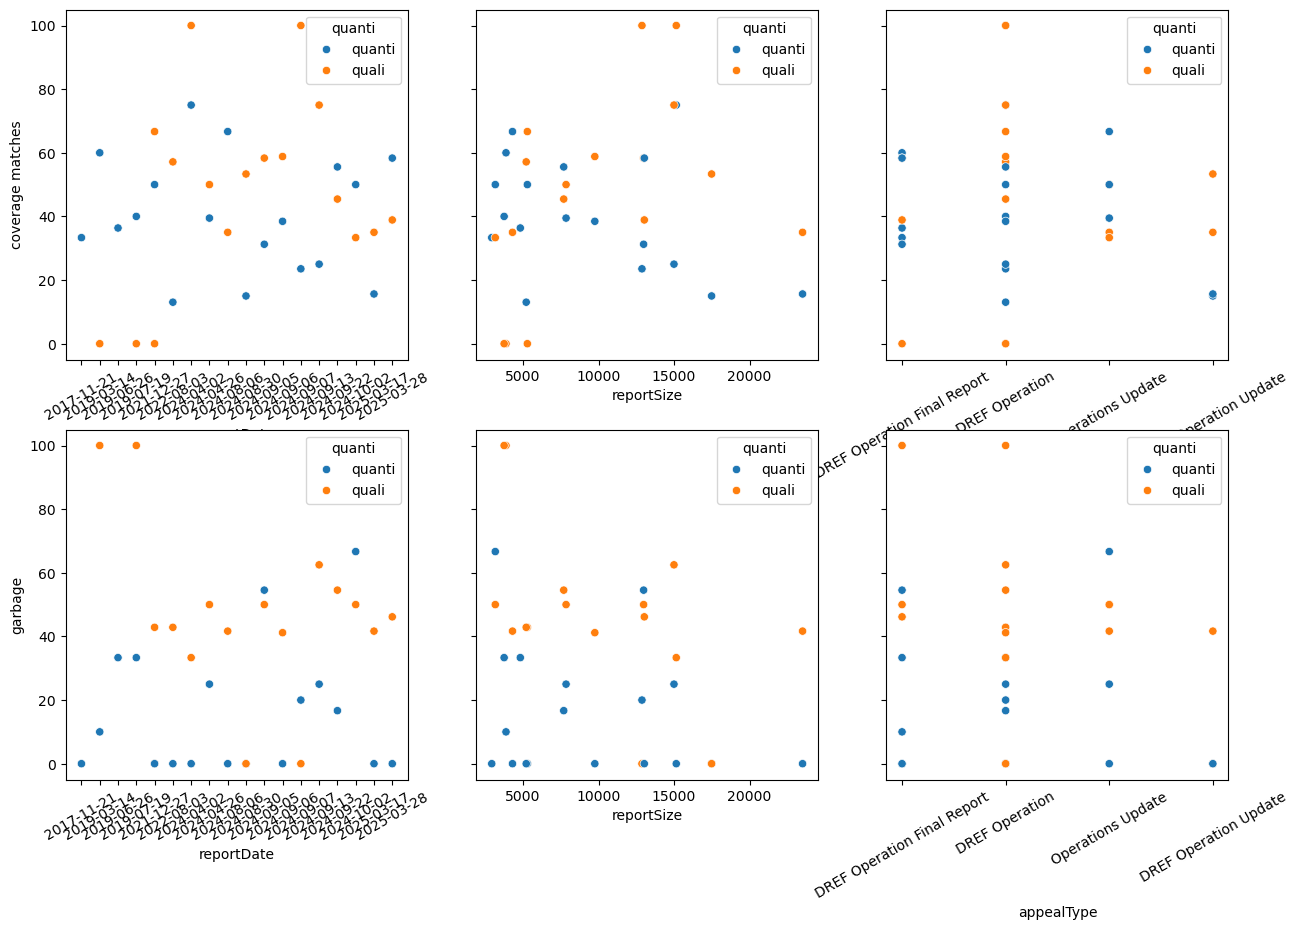

In [ ]:
#inspect sensitivity to other variables e.g. date report type, lentgth
external_vars = ["reportDate", "reportSize", "appealType"]
fig, axes = plt.subplots(2, len(external_vars), figsize=(15, 10), sharey=True, sharex=False)
coverage_df_match_appeal = coverage_df_match_appeal.sort_values("reportDate")
for i, var in enumerate(external_vars):
    sns.scatterplot(coverage_df_match_appeal, x=var, y="coverage matches", hue="quanti", ax=axes[0, i])
    sns.scatterplot(coverage_df_match_appeal, x=var, y="garbage", hue="quanti", ax=axes[1, i])
    if var in ["reportDate", "appealType"]:
        axes[0, i].set_xticklabels(axes[0, i].get_xticklabels(), rotation=30)
        axes[1, i].set_xticklabels(axes[1, i].get_xticklabels(), rotation=30)
fig.savefig(DATA_FIGURE / f"coverage_matches_by_{yvar}_external_vars_valerr_th-{value_error_th}_sim_th-{sim_th}_{filename_match}.png", bbox_inches="tight", dpi=300)

In [ ]:
#inspect sensitivity to thresholds

value_error_ths = np.arange(0.01, 0.3, 0.01)
sim_ths = np.arange(0.2, 1, 0.1)
vth_scores = []
for vth in value_error_ths:
    matched_df_filter = filter_matches(matched_df, value_error_th=vth, sim_th=0.6)
    make_coverage_accuracy_df(extracted_df, labelled_df, matched_df_filter, group_key=None)
    vth_scores.append(make_coverage_accuracy_df(extracted_df, labelled_df, matched_df_filter, group_key=None).set_index("quanti",drop=True)[["coverage matches", "garbage"]])

sth_scores = []
for sth in sim_ths:
    matched_df_filter = filter_matches(matched_df, value_error_th=0.1, sim_th=sth)
    sth_scores.append(make_coverage_accuracy_df(extracted_df, labelled_df, matched_df_filter, group_key=None).set_index("quanti",drop=True)[["coverage matches", "garbage"]])


Overall average quanti: 176 extracted, 336 labelled, 96 correct matches, 80 garbage matches
Overall average quali: 146 extracted, 174 labelled, 65 correct matches, 81 garbage matches
Overall average quanti: 176 extracted, 336 labelled, 96 correct matches, 80 garbage matches
Overall average quali: 146 extracted, 174 labelled, 65 correct matches, 81 garbage matches
Overall average quanti: 176 extracted, 336 labelled, 97 correct matches, 79 garbage matches
Overall average quali: 146 extracted, 174 labelled, 65 correct matches, 81 garbage matches
Overall average quanti: 176 extracted, 336 labelled, 97 correct matches, 79 garbage matches
Overall average quali: 146 extracted, 174 labelled, 65 correct matches, 81 garbage matches
Overall average quanti: 176 extracted, 336 labelled, 98 correct matches, 78 garbage matches
Overall average quali: 146 extracted, 174 labelled, 65 correct matches, 81 garbage matches
Overall average quanti: 176 extracted, 336 labelled, 98 correct matches, 78 garbage m

<Axes: >

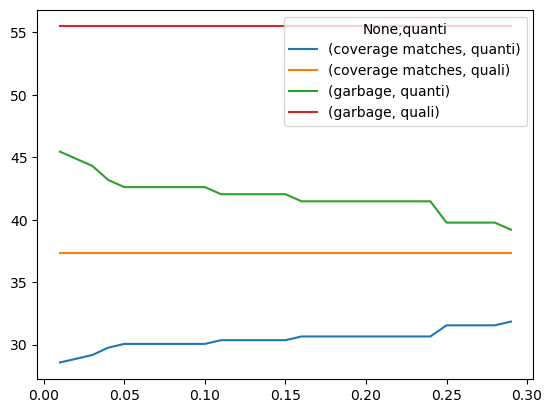

In [ ]:
sensi_vth_df = pd.concat(vth_scores, keys=value_error_ths).unstack()
sensi_vth_df.plot()

<Axes: >

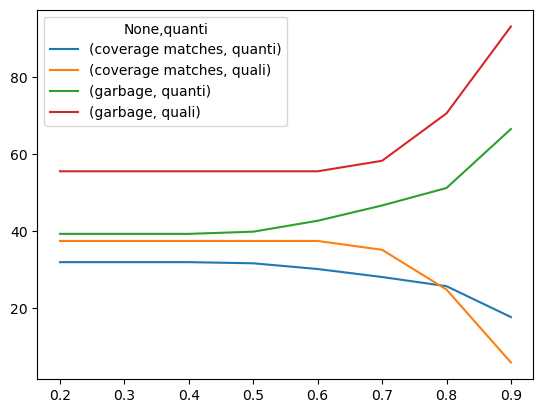

In [ ]:
sensi_sth_df = pd.concat(sth_scores, keys=sim_ths).unstack()
sensi_sth_df.plot()

In [ ]:
## Compare coverage by categories between labelled and extracted for all impacts

keys = ["meta-llama_llama-4-scout-17b-16e-instruct", "llama-3.1-8b-instant", "llama-3.3-70b-versatile"]
key = keys[0]
extracted_lab_name = f"merged_subtypes_post_processed_labelled_reports_fixed_impact_desc_{key}_v271025"
extracted_all_name = f"merged_subtypes_post_processed_all_appeals_unique_1-333_{key}_v281025"

extracted_lab = pd.read_csv(DATA_OUT_PROC / (extracted_lab_name+".csv"))
extracted_df_long = pd.read_csv(DATA_OUT_PROC / (extracted_all_name+".csv"))


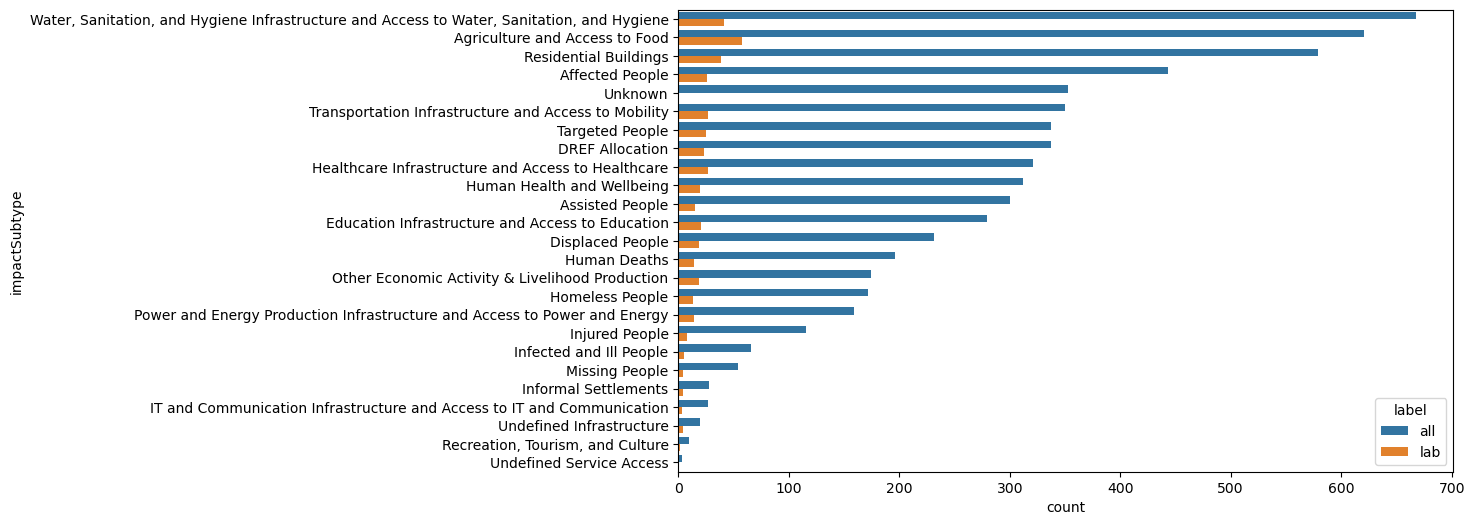

In [ ]:
#merge dfs
extracted_lab["label"] ="lab"
extracted_df_long["label"] = "all"
extracted_df_all = pd.concat([extracted_lab, extracted_df_long])
plot_df = extracted_df_all.value_counts(["impactSubtype", "label"]).reset_index()
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
sns.barplot(data=plot_df, x="count", y="impactSubtype", hue="label", axes=ax)
fig.savefig(DATA_FIGURE / f"impactSubtype_distr_lab_vs_333_{extracted_lab_name}.png", bbox_inches="tight", dpi=300)
